In [1]:
import os
import json
from graphviz import Digraph
from PIL import Image
import matplotlib.pyplot as plt

In [17]:
def parse_logic_to_tree(logic, graph, parent=None, node_id=0):
    if 'raw_text' in logic:
        node_label = logic['raw_text']
        graph.node(str(node_id), label=node_label, shape='box')
        if parent is not None:
            graph.edge(parent, str(node_id))
        return node_id

    for key in logic:
        if key in ('AND', 'OR', 'NOT'):
            operator = key
            node_label = operator
            current_node_id = node_id
            color = 'lightblue' if operator == 'AND' else 'lightgreen' if operator == 'OR' else 'lightcoral'
            graph.node(str(current_node_id), label=node_label, color=color, fontcolor='black', style='filled', fillcolor=color)
            if parent is not None:
                graph.edge(parent, str(current_node_id))

            operands = logic[key]
            node_id += 1
            if 'left' in operands:
                left_id = parse_logic_to_tree(operands['left'], graph, str(current_node_id), node_id)
                node_id = left_id + 1
            if 'right' in operands:
                right_id = parse_logic_to_tree(operands['right'], graph, str(current_node_id), node_id)
                node_id = right_id + 1
            if operator == 'NOT':
                node_id += 1
    return node_id

def visualize_logic_tree(logic):
    graph = Digraph(format='png')
    parse_logic_to_tree(logic, graph)
    return graph

def plot_and_save_graph(logic, graph_title, output_filename):
    graph = visualize_logic_tree(logic)
    graph.render(filename='temp', view=False, cleanup=True)
    image = Image.open('temp.png')
    plt.figure(figsize=(20, 15))
    plt.imshow(image)
    plt.axis('off')
    plt.title(graph_title)
    plt.savefig(output_filename)
    #plt.close()
    plt.show()

In [18]:
model_name = "Llama3_70b_Fine-Tuned_ep10"
p2_label_path = "../../input/lct_p2"
model_input_path = f"model_output/{model_name}/ready"

picture_path = f"pics/tree/{model_name}_vs_label_pics"

n = 50

In [19]:
if not os.path.exists(picture_path):
    os.makedirs(picture_path)

label_files = [f for f in os.listdir(p2_label_path) if f.endswith(".json")][:n]
model_files = [f for f in os.listdir(model_input_path) if f.endswith(".json")][:n]

model_files

['Llama3_70b_Fine-Tuned_p3_ep10_NCT03860220_inc.json',
 'Llama3_70b_Fine-Tuned_p3_ep10_NCT03860259_inc.json',
 'Llama3_70b_Fine-Tuned_p3_ep10_NCT03860311_exc.json',
 'Llama3_70b_Fine-Tuned_p3_ep10_NCT03860324_exc.json',
 'Llama3_70b_Fine-Tuned_p3_ep10_NCT03860363_inc.json',
 'Llama3_70b_Fine-Tuned_p3_ep10_NCT03860402_exc.json',
 'Llama3_70b_Fine-Tuned_p3_ep10_NCT03860402_inc.json',
 'Llama3_70b_Fine-Tuned_p3_ep10_NCT03860428_inc.json',
 'Llama3_70b_Fine-Tuned_p3_ep10_NCT03860493_exc.json',
 'Llama3_70b_Fine-Tuned_p3_ep10_NCT03860545_inc.json',
 'Llama3_70b_Fine-Tuned_p3_ep10_NCT03860597_inc.json',
 'Llama3_70b_Fine-Tuned_p3_ep10_NCT03860610_inc.json',
 'Llama3_70b_Fine-Tuned_p3_ep10_NCT03860623_inc.json',
 'Llama3_70b_Fine-Tuned_p3_ep10_NCT03860662_inc.json',
 'Llama3_70b_Fine-Tuned_p3_ep10_NCT03860688_exc.json',
 'Llama3_70b_Fine-Tuned_p3_ep10_NCT03860701_inc.json',
 'Llama3_70b_Fine-Tuned_p3_ep10_NCT03860753_exc.json',
 'Llama3_70b_Fine-Tuned_p3_ep10_NCT03860766_exc.json',
 'Llama3_7

In [20]:
# Model vs Label muss überarbeitet werden 
for label_file in label_files:
    base_name = label_file.split(".json")[0]

    model = model_name.split("_")[0]
    nshot = model_name.split("_")[1]
    model_file = f"{model}_{base_name}.json"
    print(model_file)
    if model_file in model_files:
        label_file_path = os.path.join(p2_label_path, label_file)
        model_file_path = os.path.join(model_input_path, model_file)
        with open(label_file_path, 'r', encoding='utf-8') as f:
            label_data = json.load(f)

        print("label data: ", label_data)
        with open(model_file_path, 'r', encoding='utf-8') as f:
            model_data = json.load(f)

        label_output_path = os.path.join(picture_path, f"{base_name}_label.png")
        model_output_path = os.path.join(picture_path, f"{base_name}_model.png")

        plot_and_save_graph(label_data, f"Label: {base_name}", label_output_path)
        plot_and_save_graph(model_data, f"Model: {base_name}", model_output_path)

Llama3_NCT03860012_exc.json_70b_shot.json
Llama3_NCT03860012_inc.json_70b_shot.json
Llama3_NCT03860025_exc.json_70b_shot.json
Llama3_NCT03860025_inc.json_70b_shot.json
Llama3_NCT03860038_exc.json_70b_shot.json
Llama3_NCT03860038_inc.json_70b_shot.json
Llama3_NCT03860064_exc.json_70b_shot.json
Llama3_NCT03860064_inc.json_70b_shot.json
Llama3_NCT03860090_exc.json_70b_shot.json
Llama3_NCT03860090_inc.json_70b_shot.json
Llama3_NCT03860103_exc.json_70b_shot.json
Llama3_NCT03860103_inc.json_70b_shot.json
Llama3_NCT03860116_exc.json_70b_shot.json
Llama3_NCT03860116_inc.json_70b_shot.json
Llama3_NCT03860142_exc.json_70b_shot.json
Llama3_NCT03860142_inc.json_70b_shot.json
Llama3_NCT03860168_exc.json_70b_shot.json
Llama3_NCT03860168_inc.json_70b_shot.json
Llama3_NCT03860181_exc.json_70b_shot.json
Llama3_NCT03860181_inc.json_70b_shot.json
Llama3_NCT03860194_exc.json_70b_shot.json
Llama3_NCT03860194_inc.json_70b_shot.json
Llama3_NCT03860220_exc.json_70b_shot.json
Llama3_NCT03860220_inc.json_70b_sh

### Plot label trees only

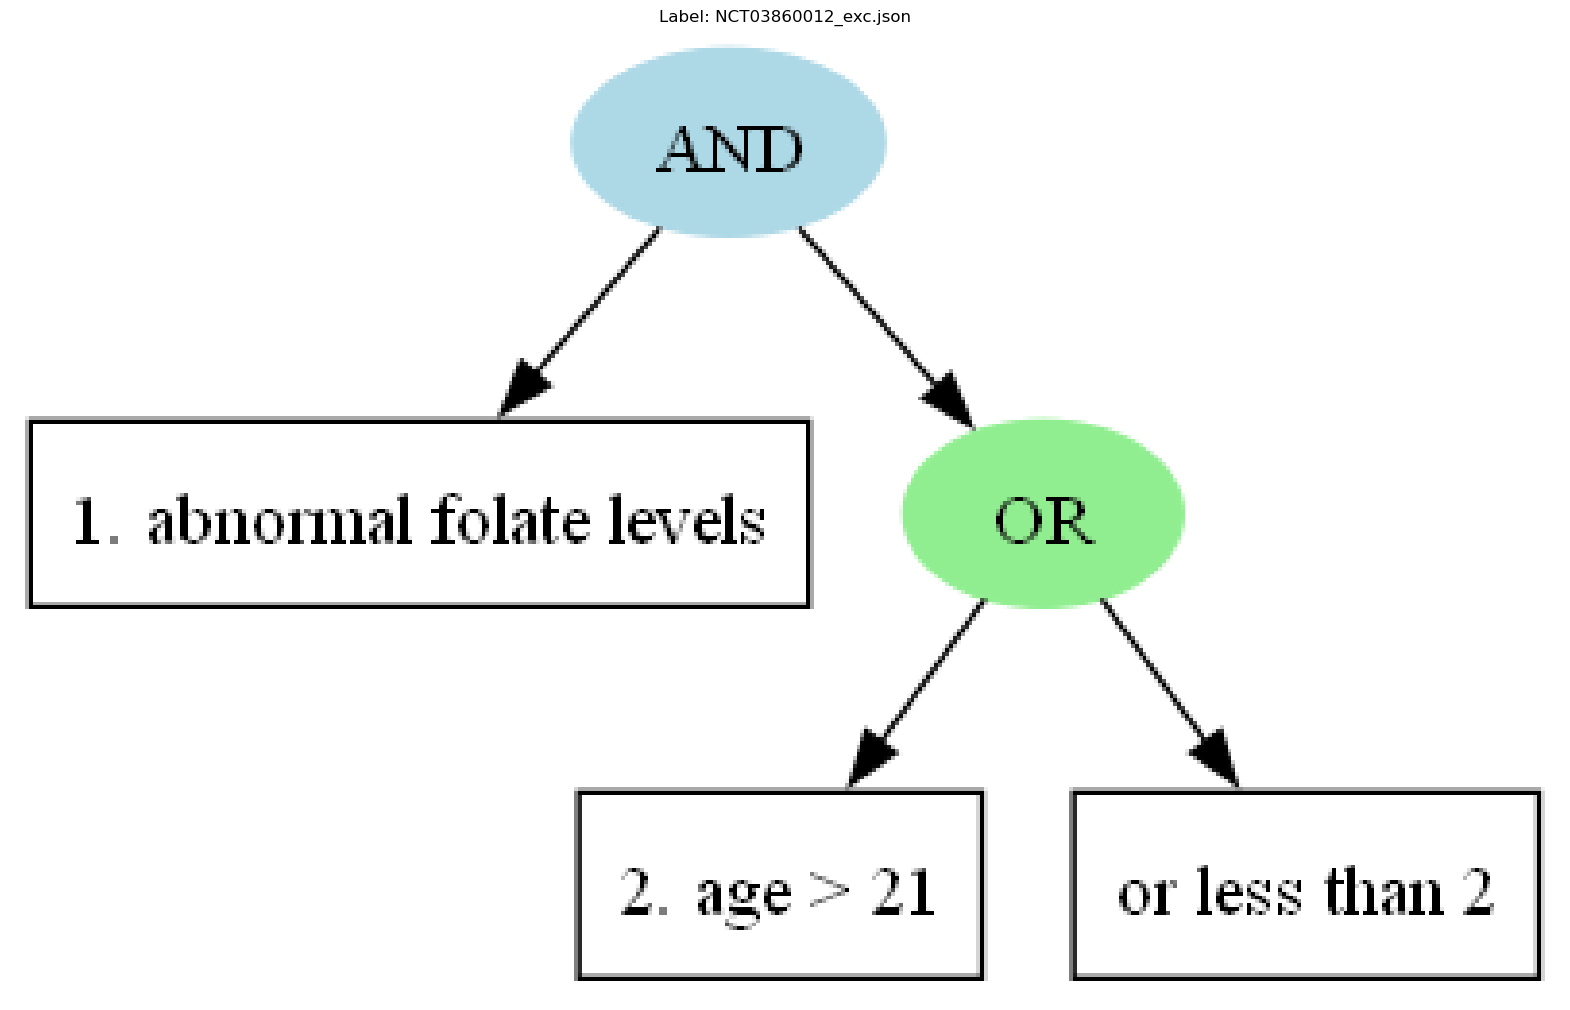

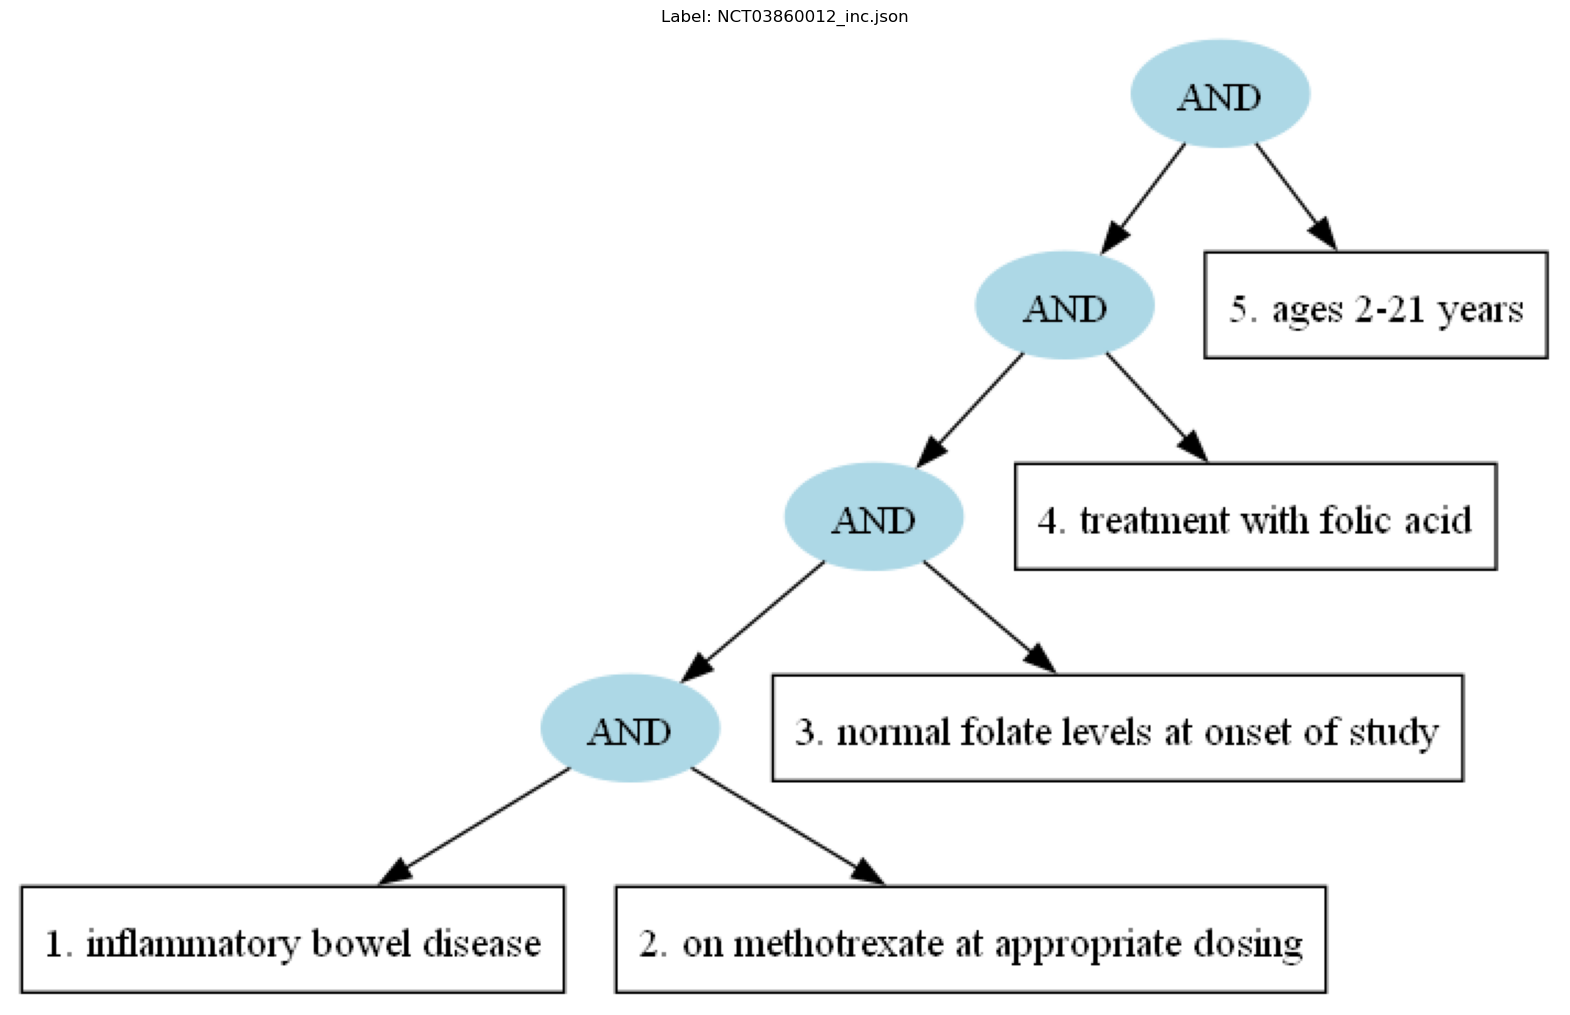

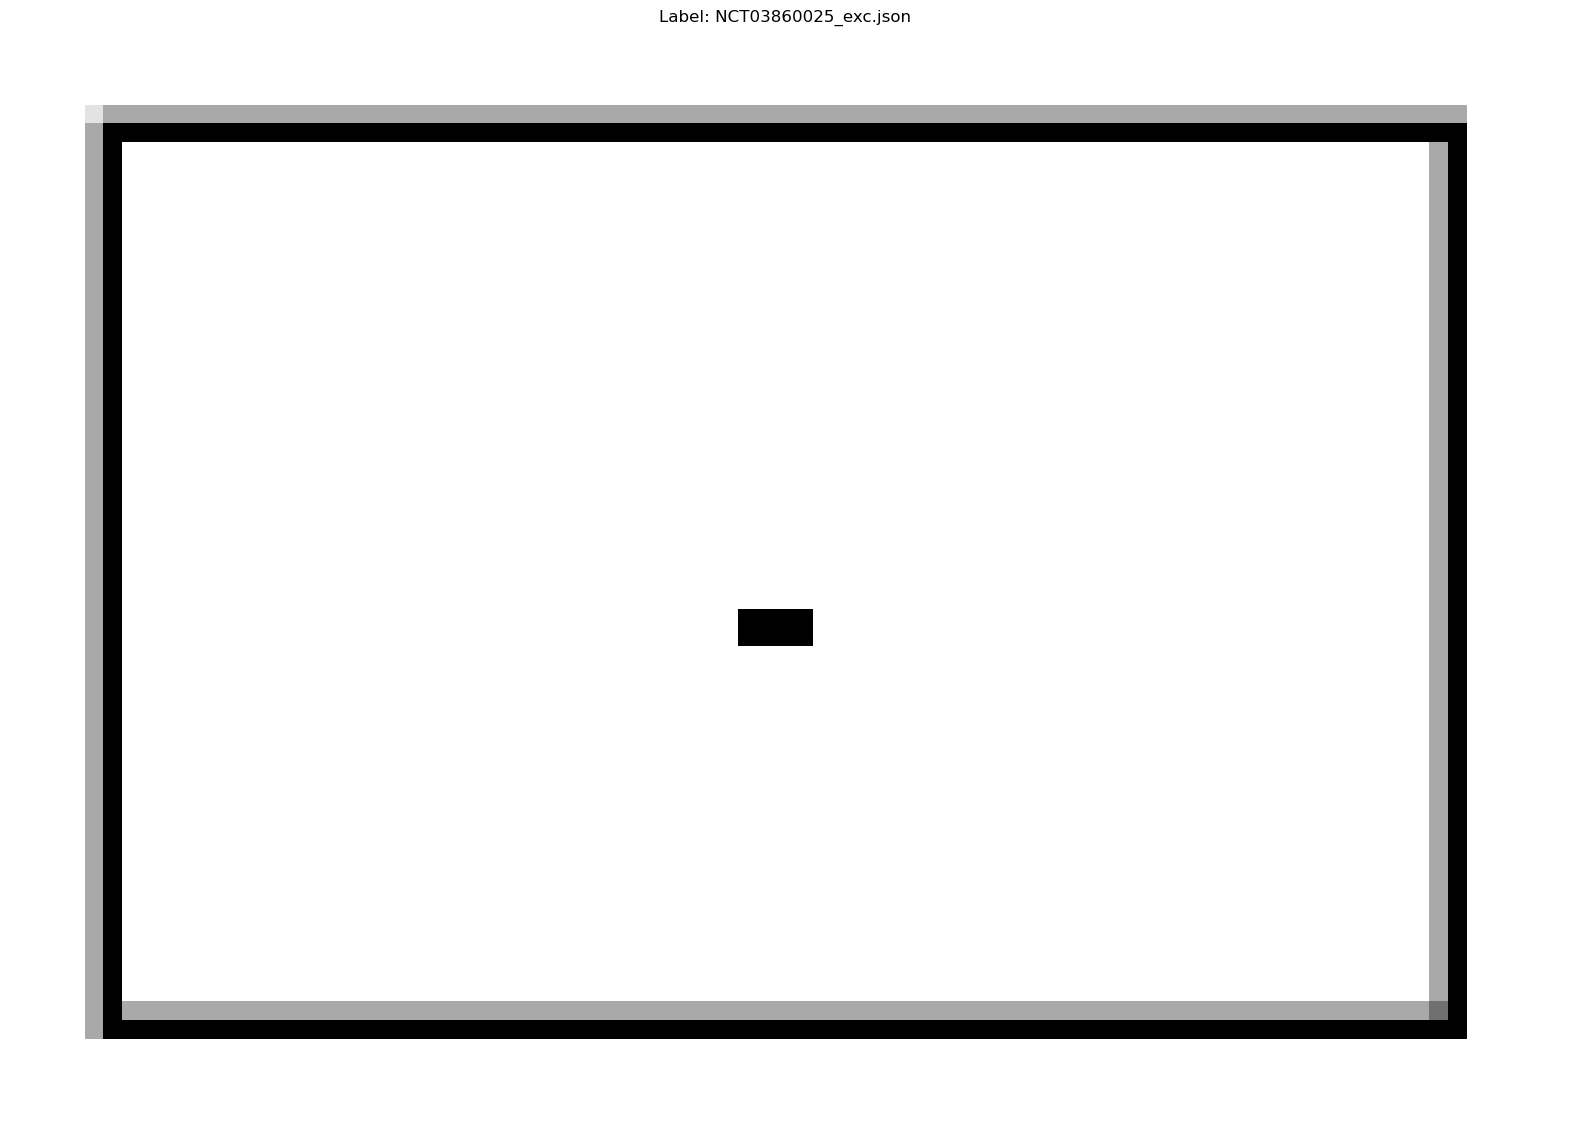

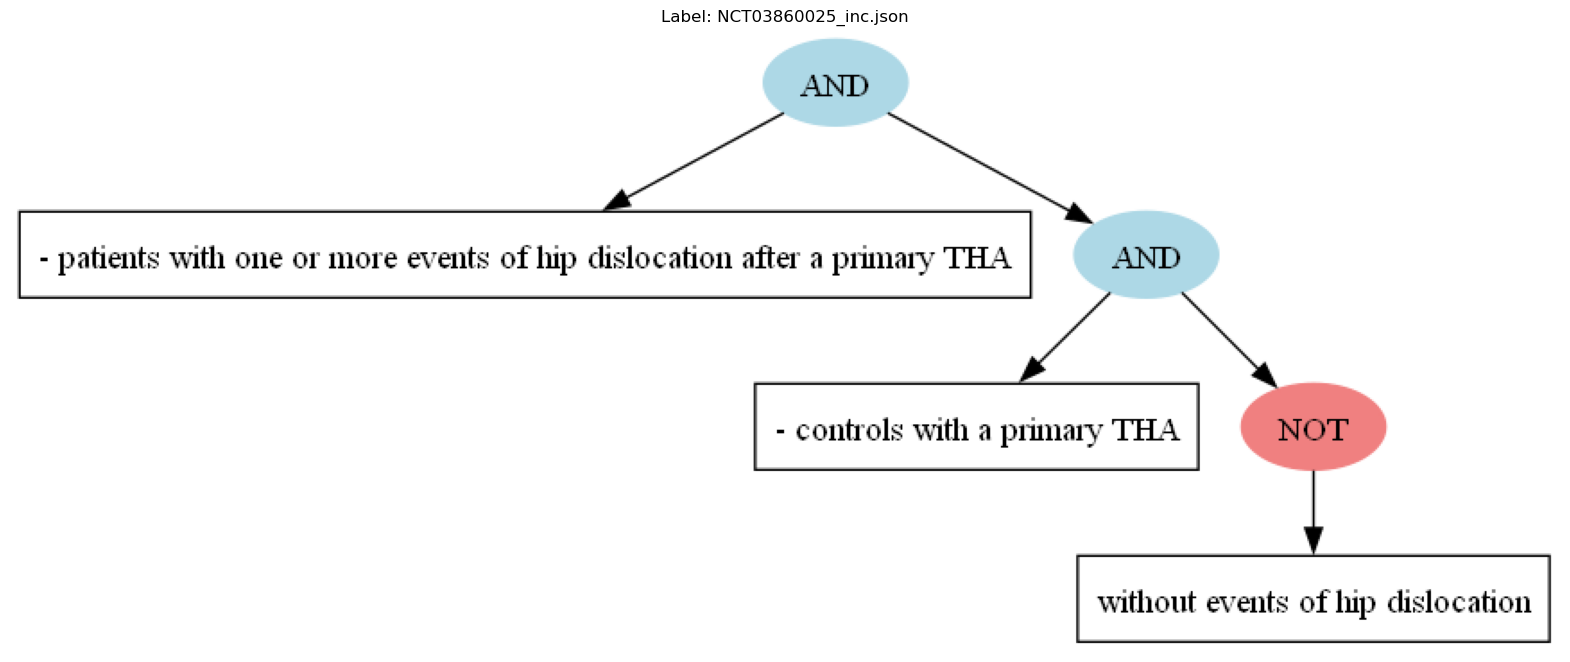

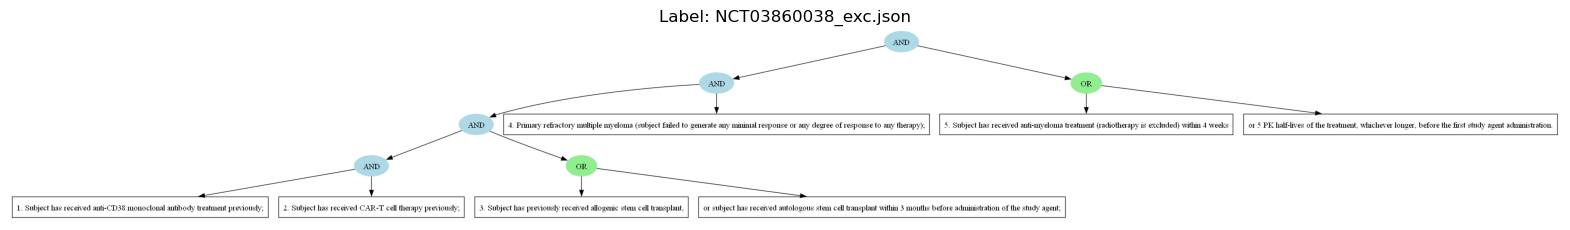

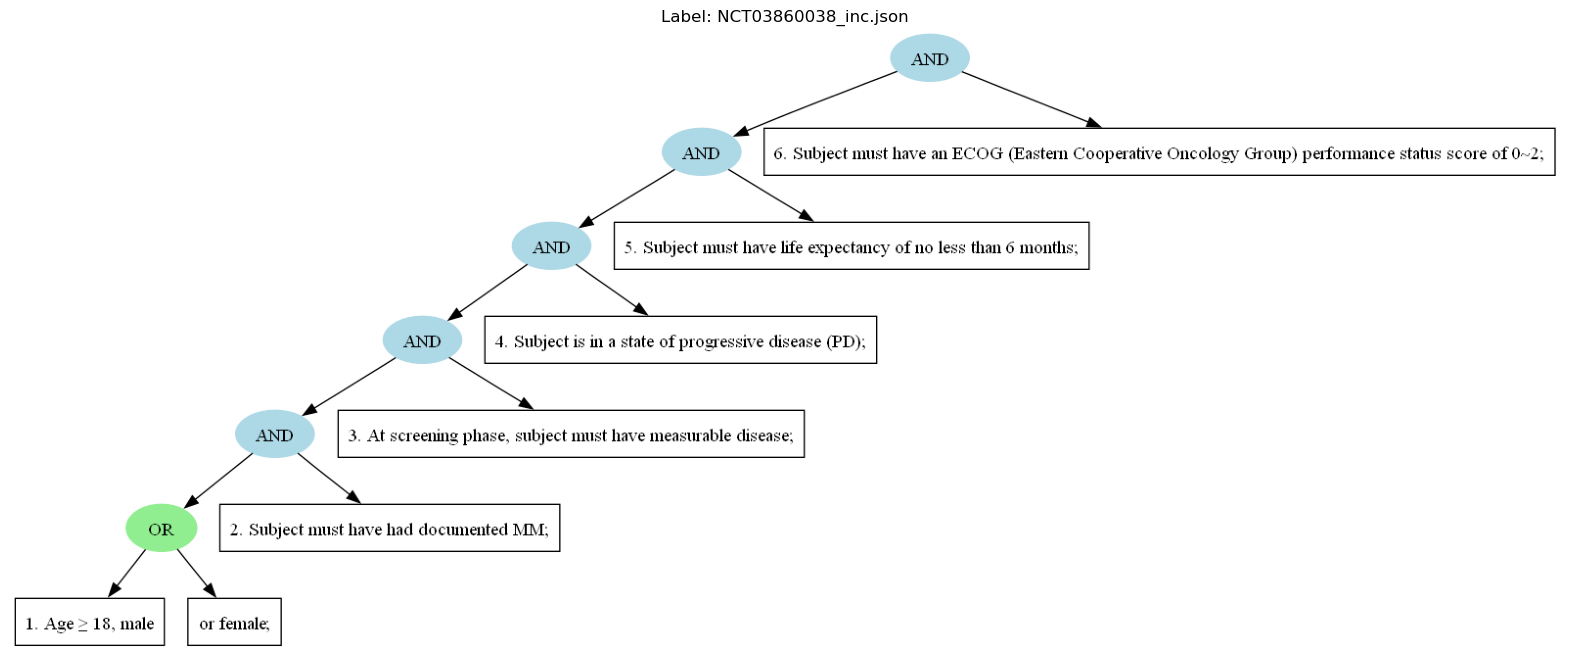

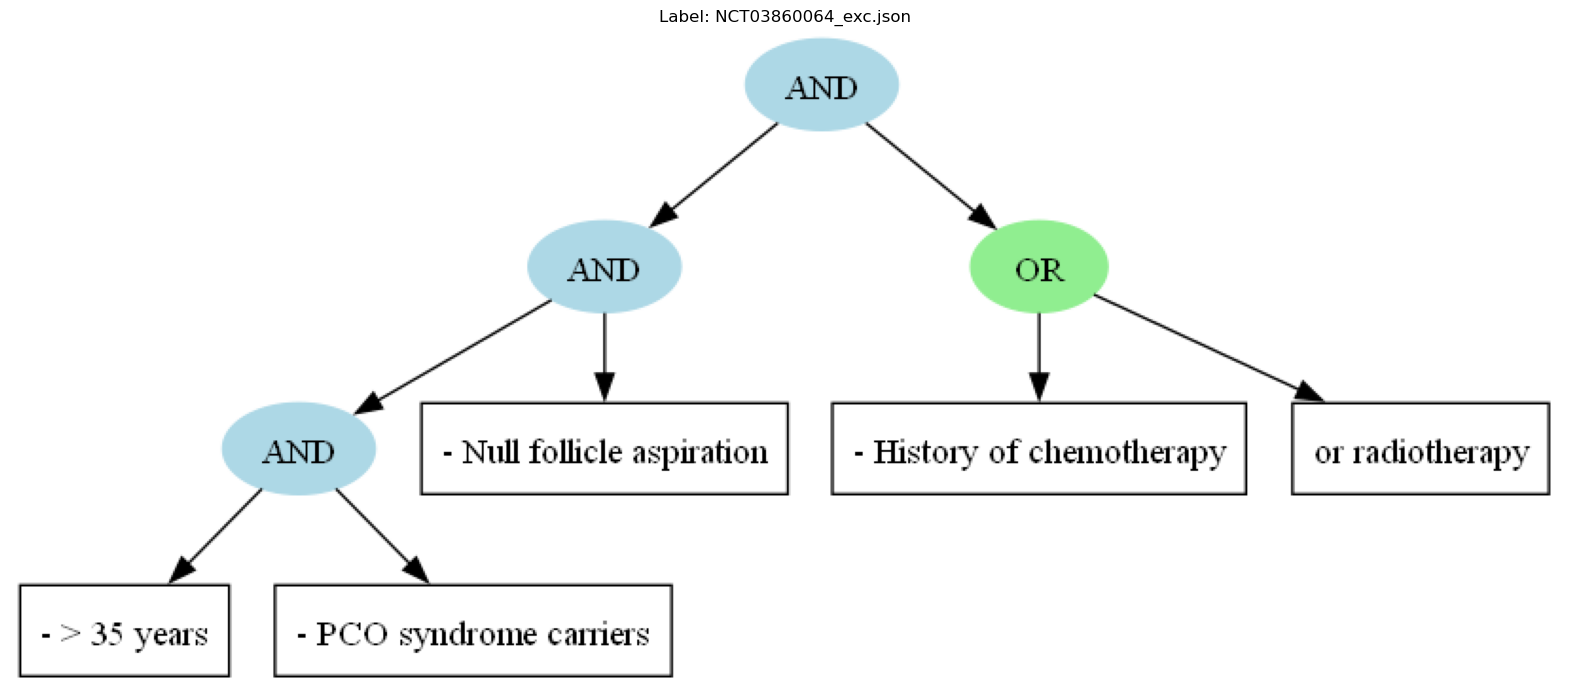

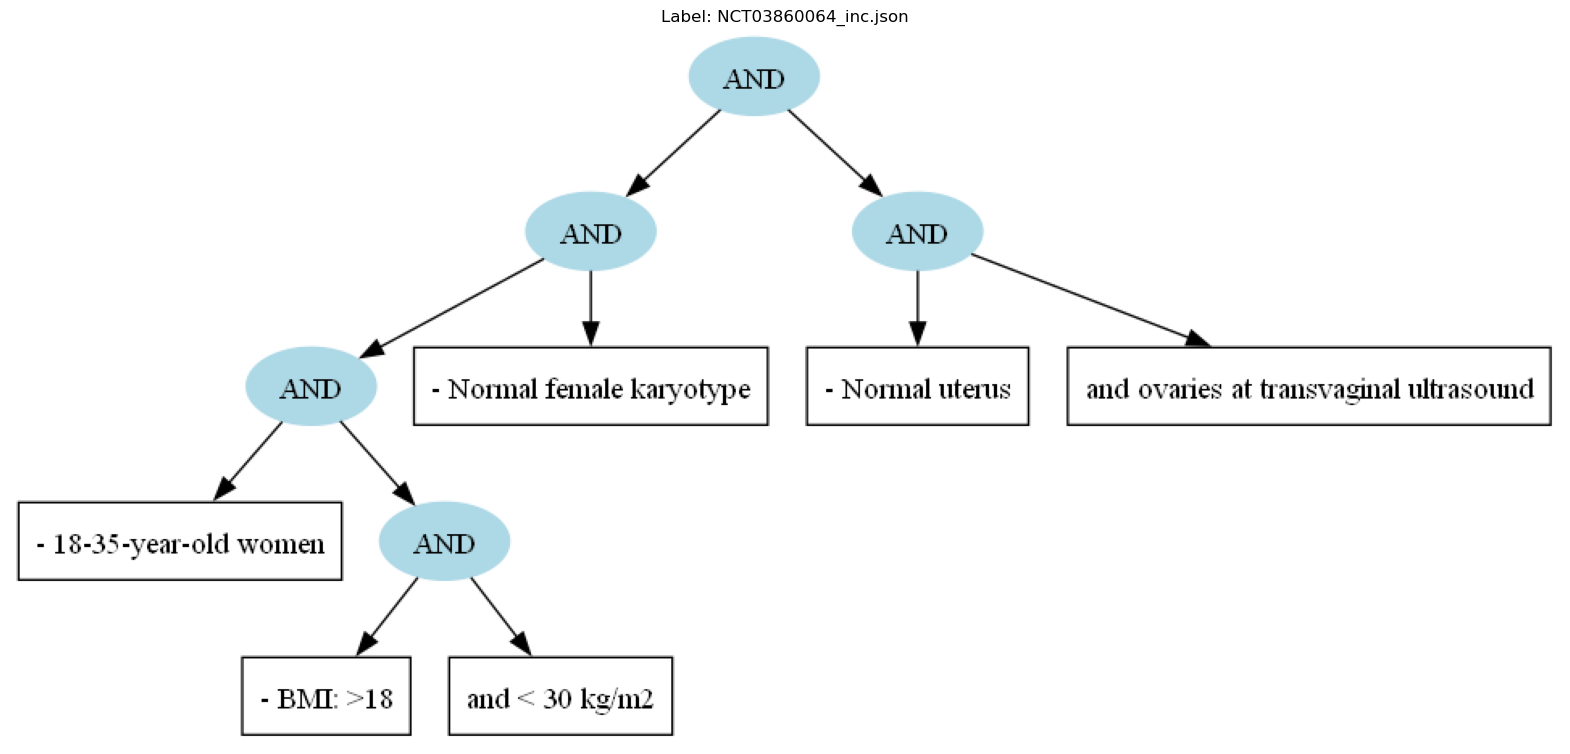

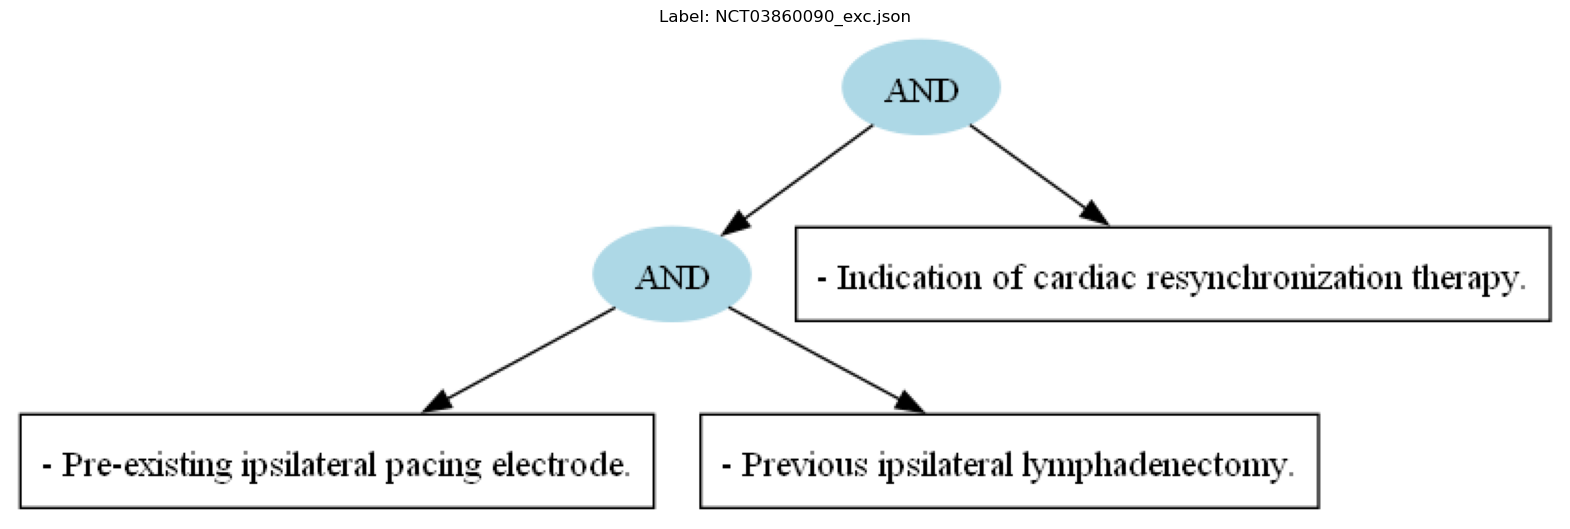

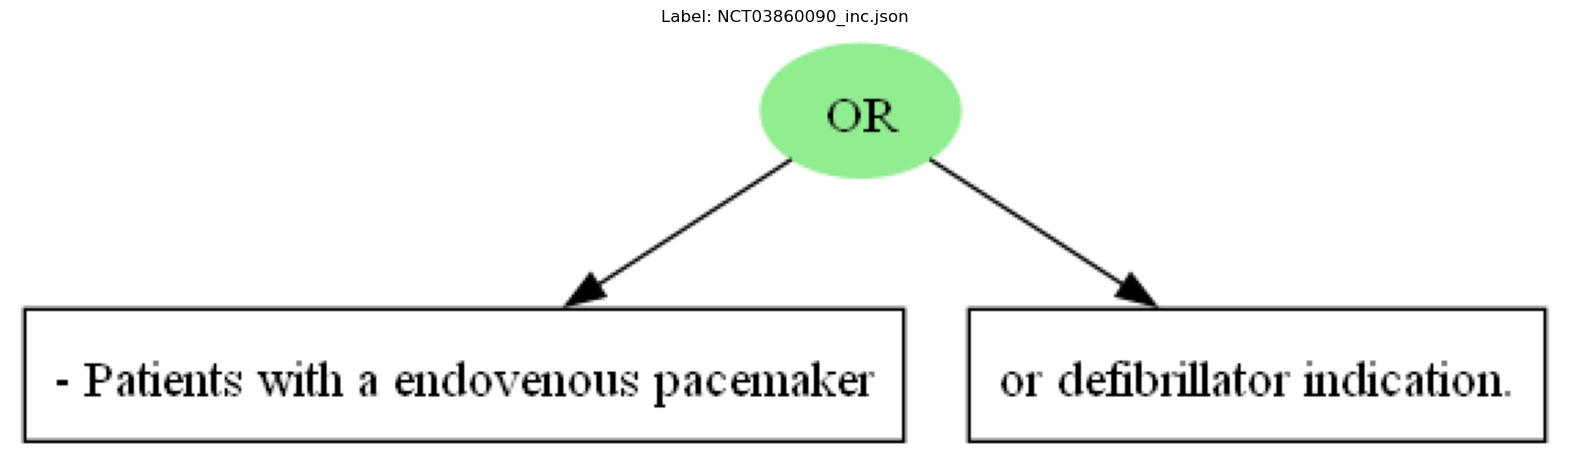

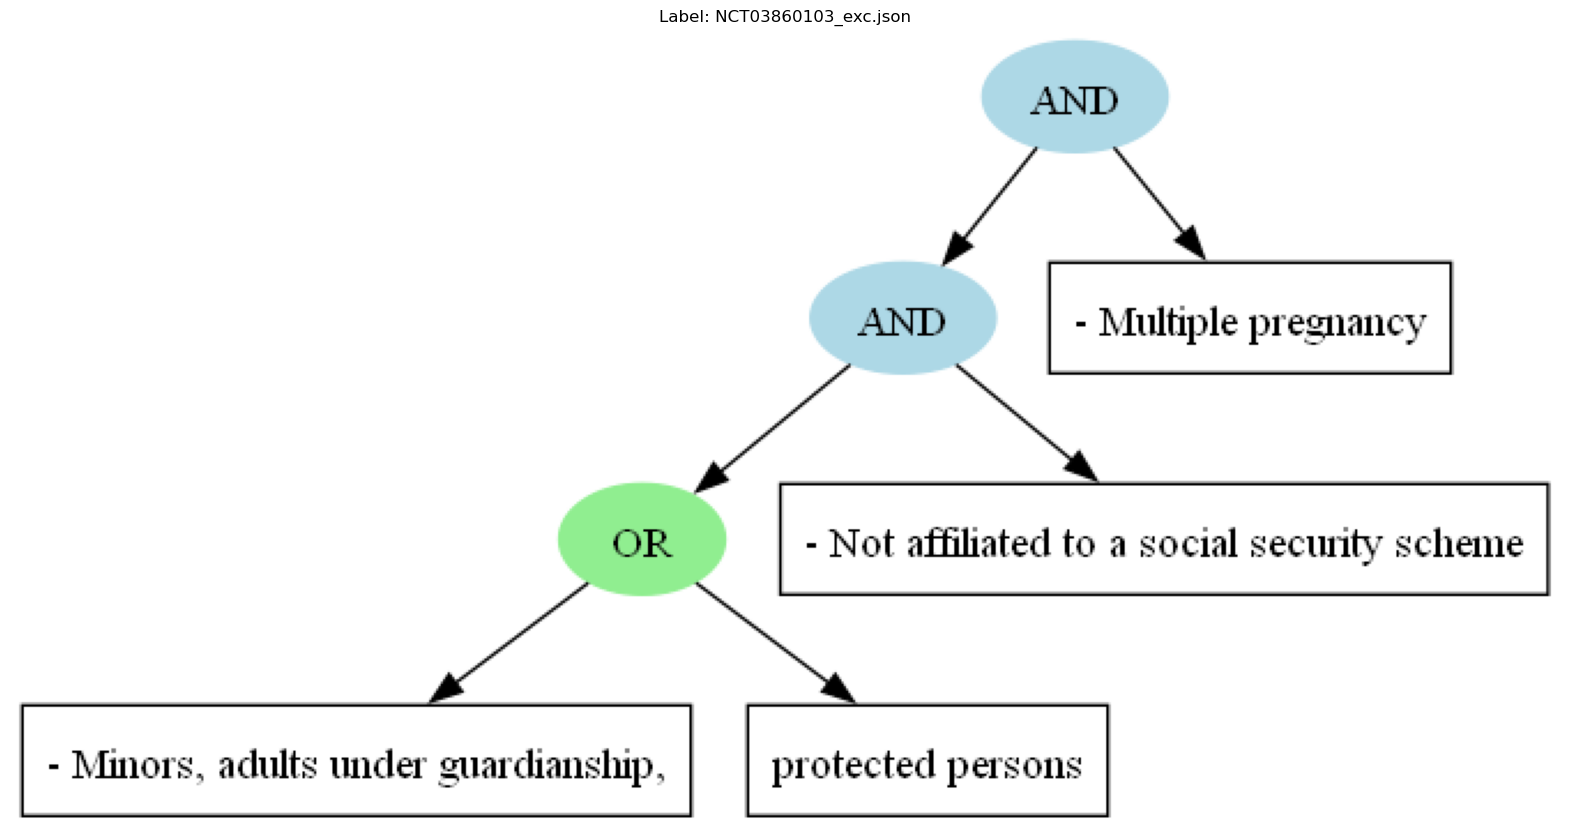

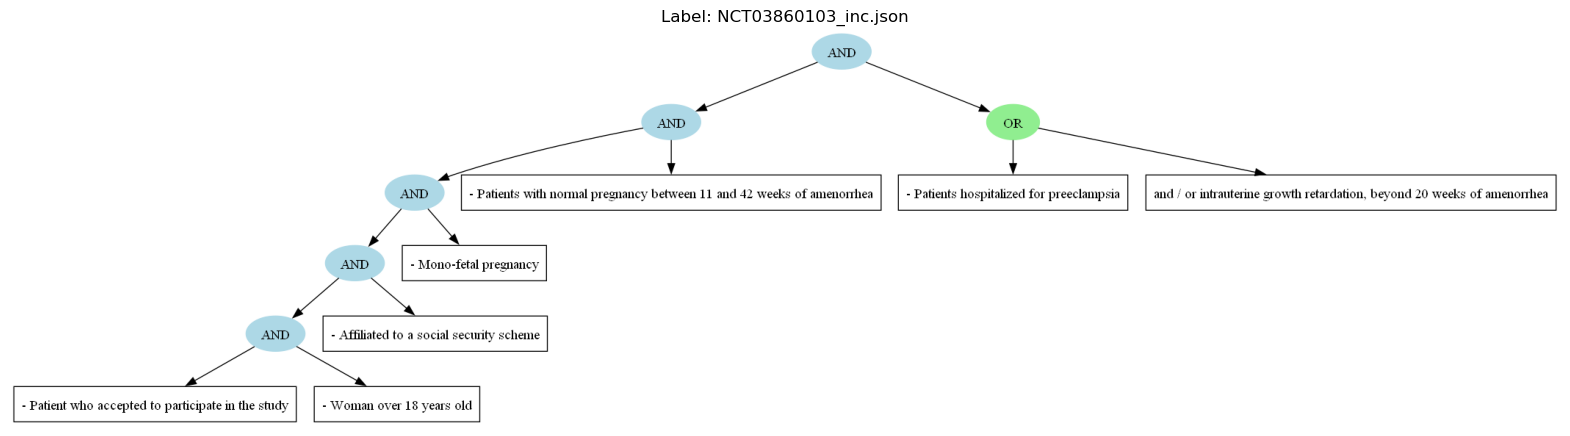

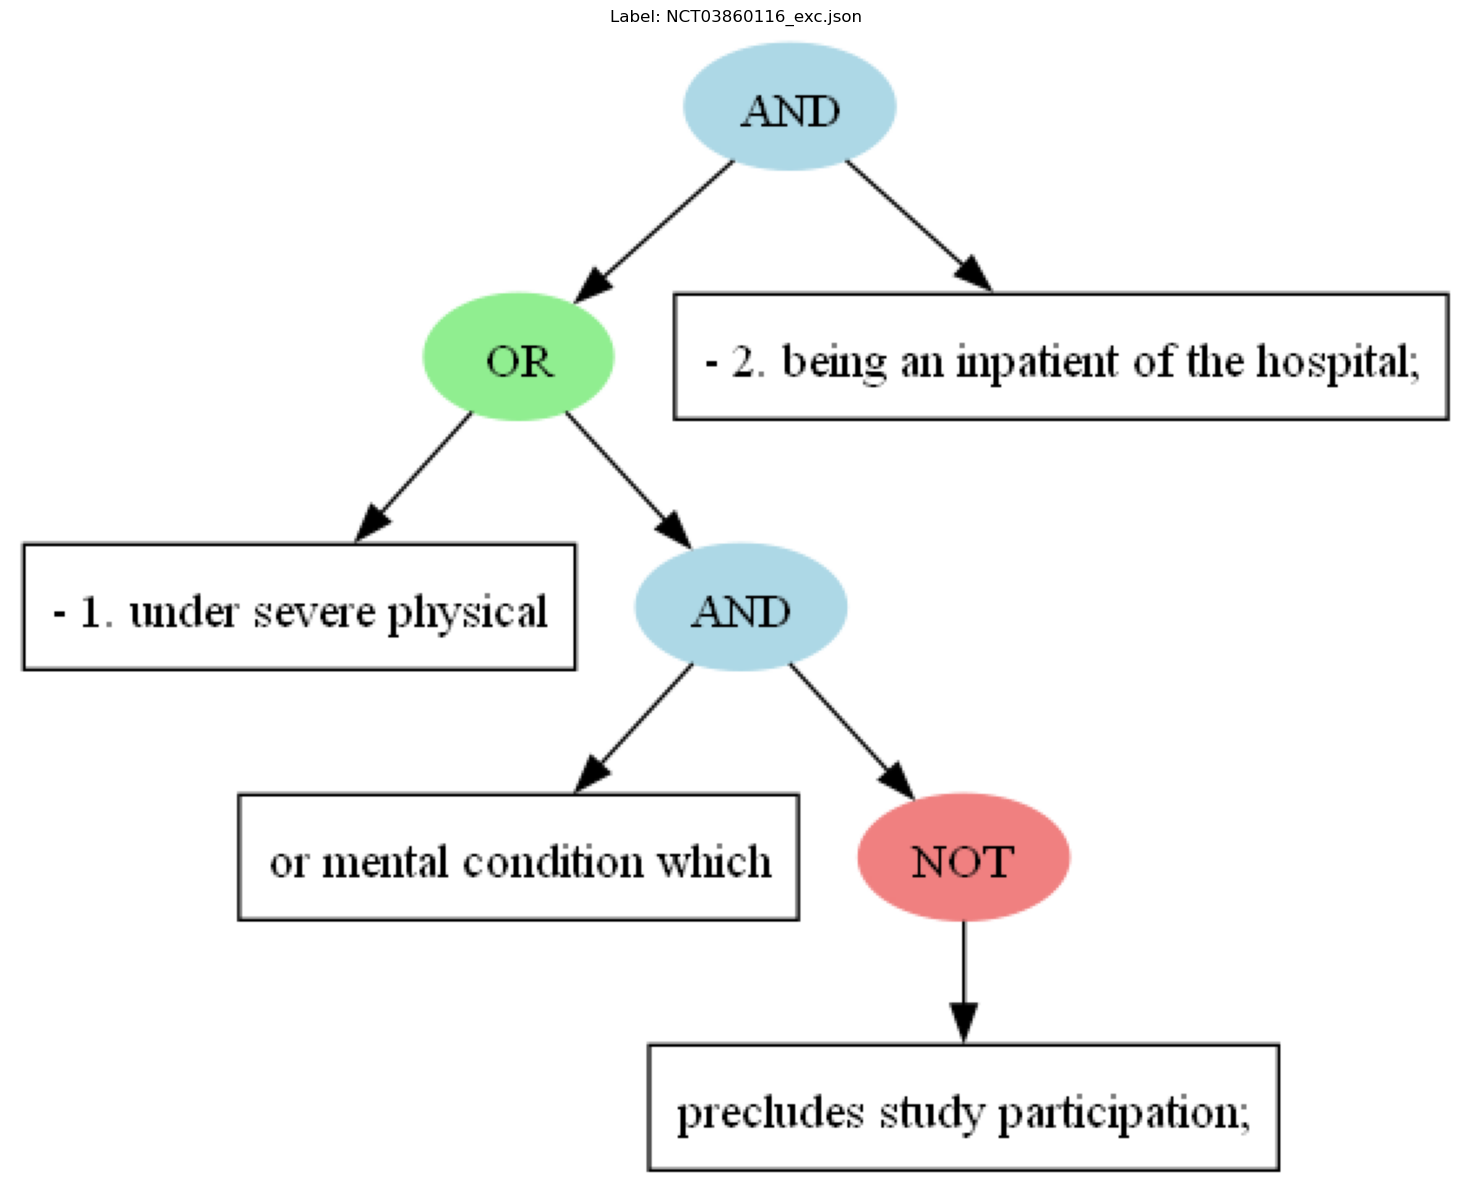

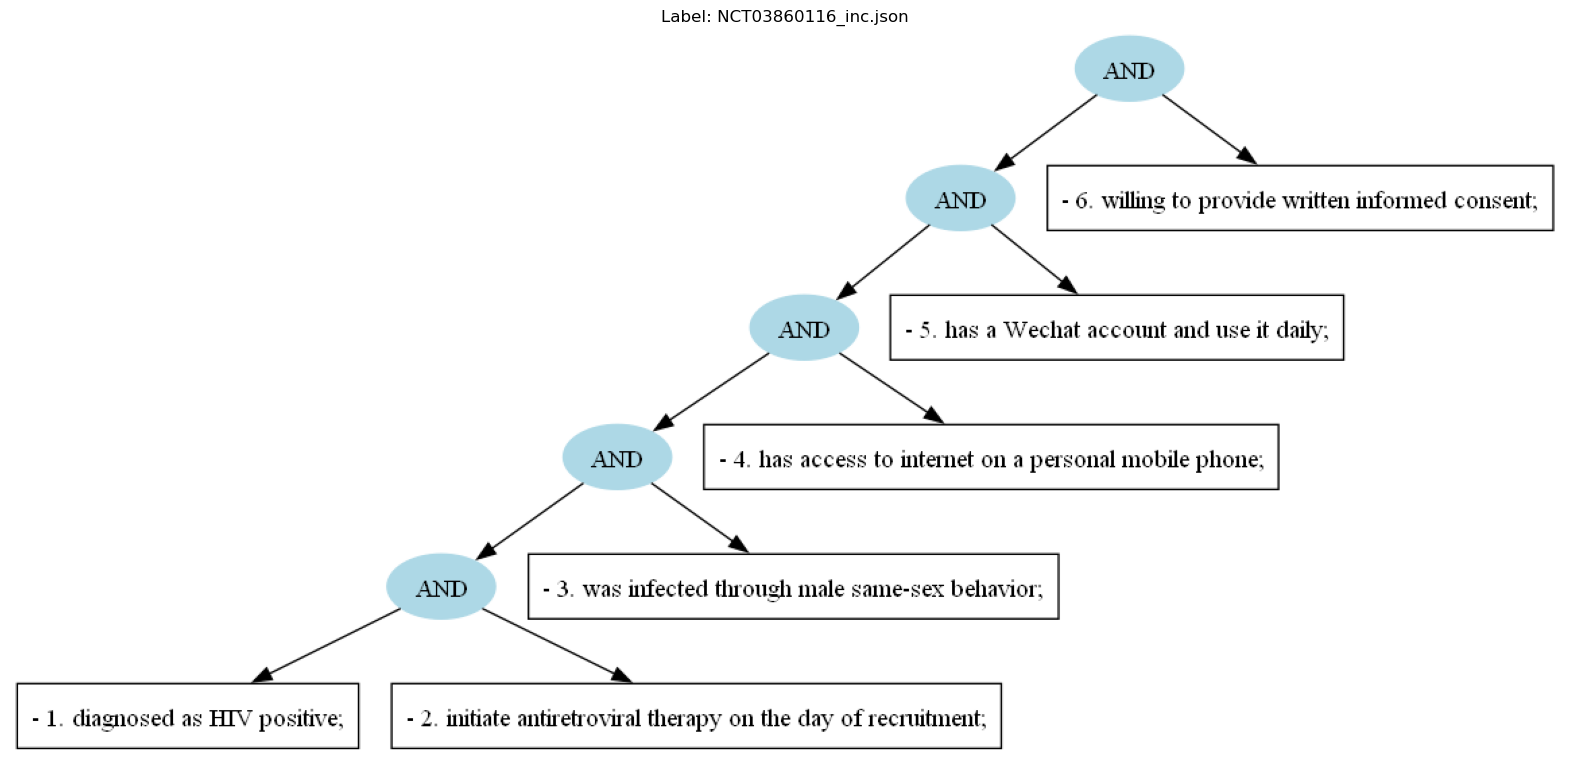

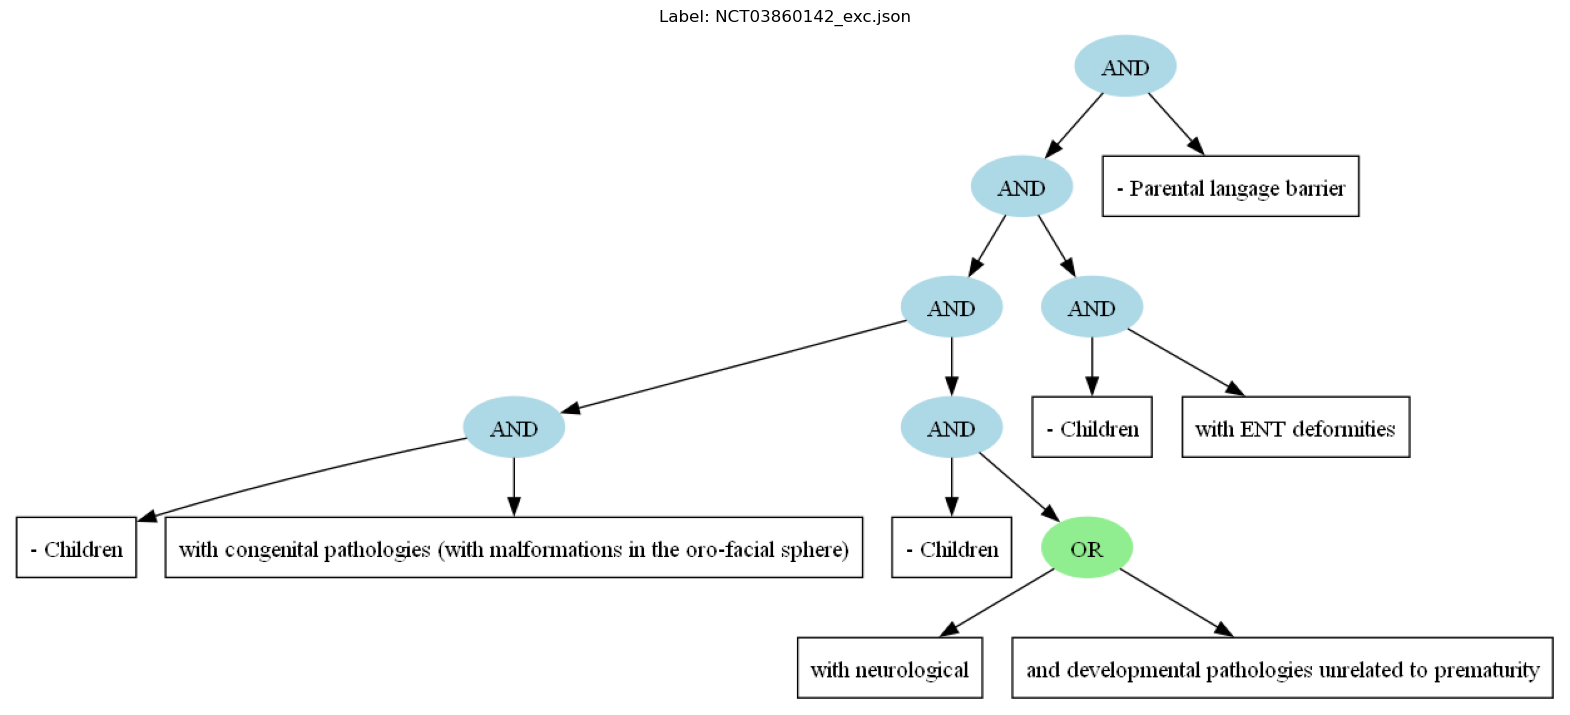

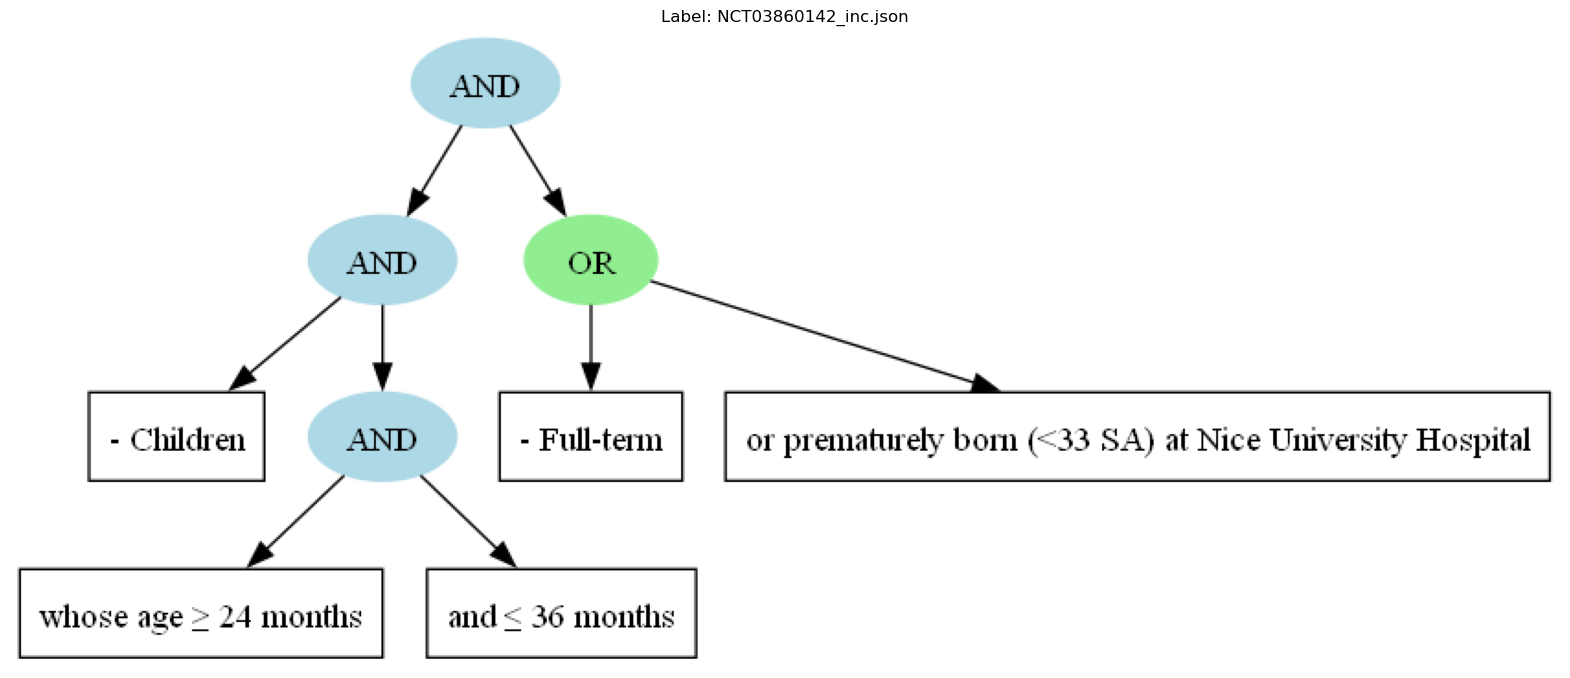

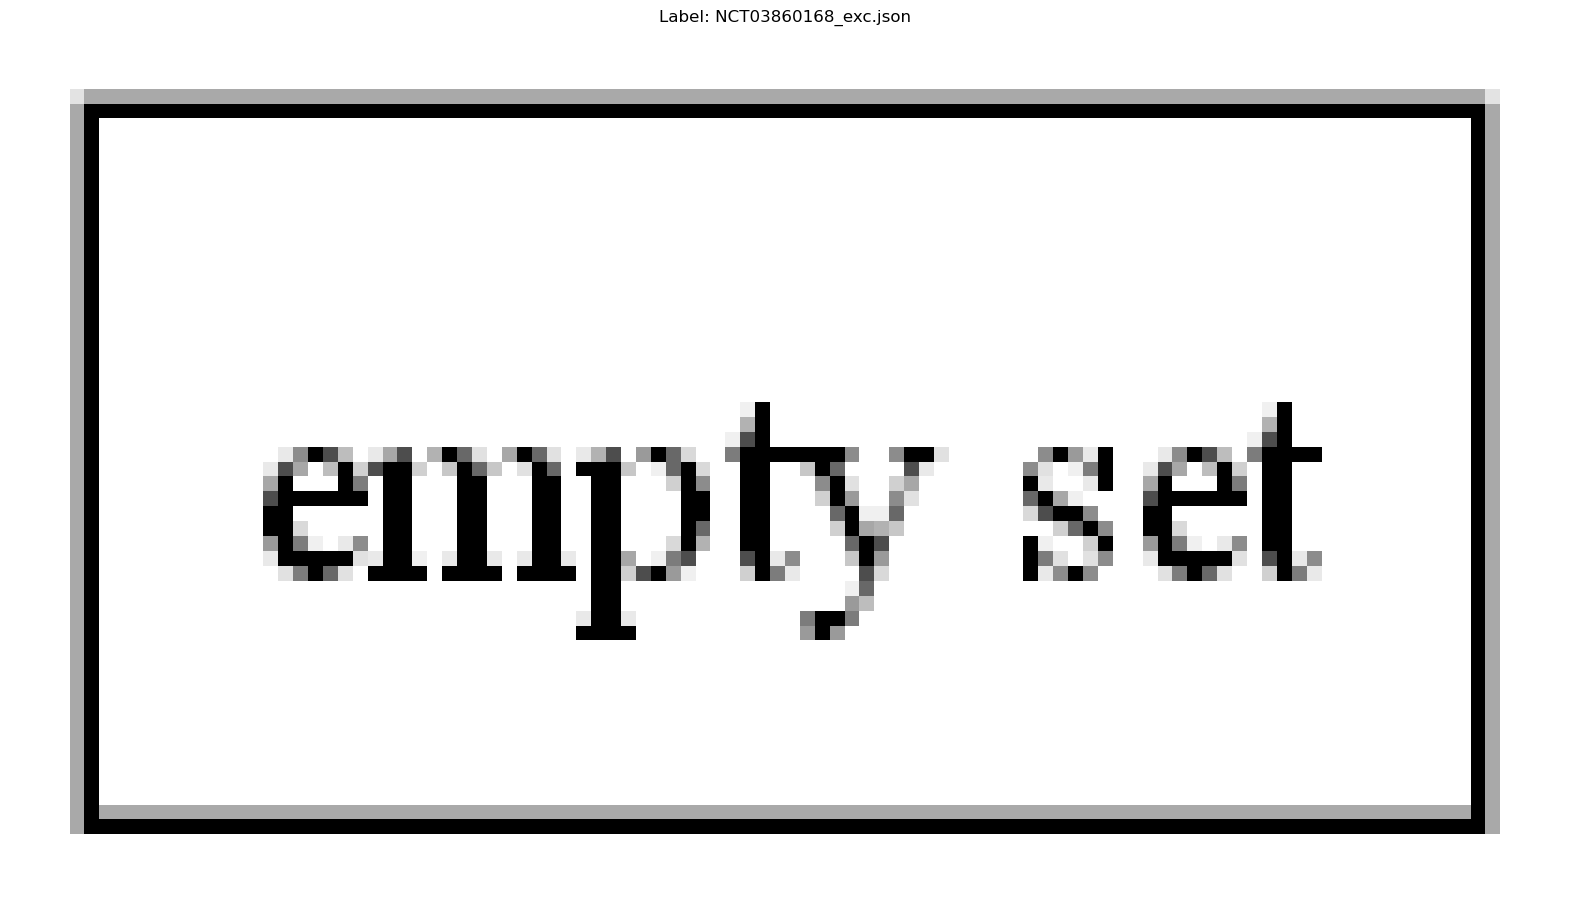

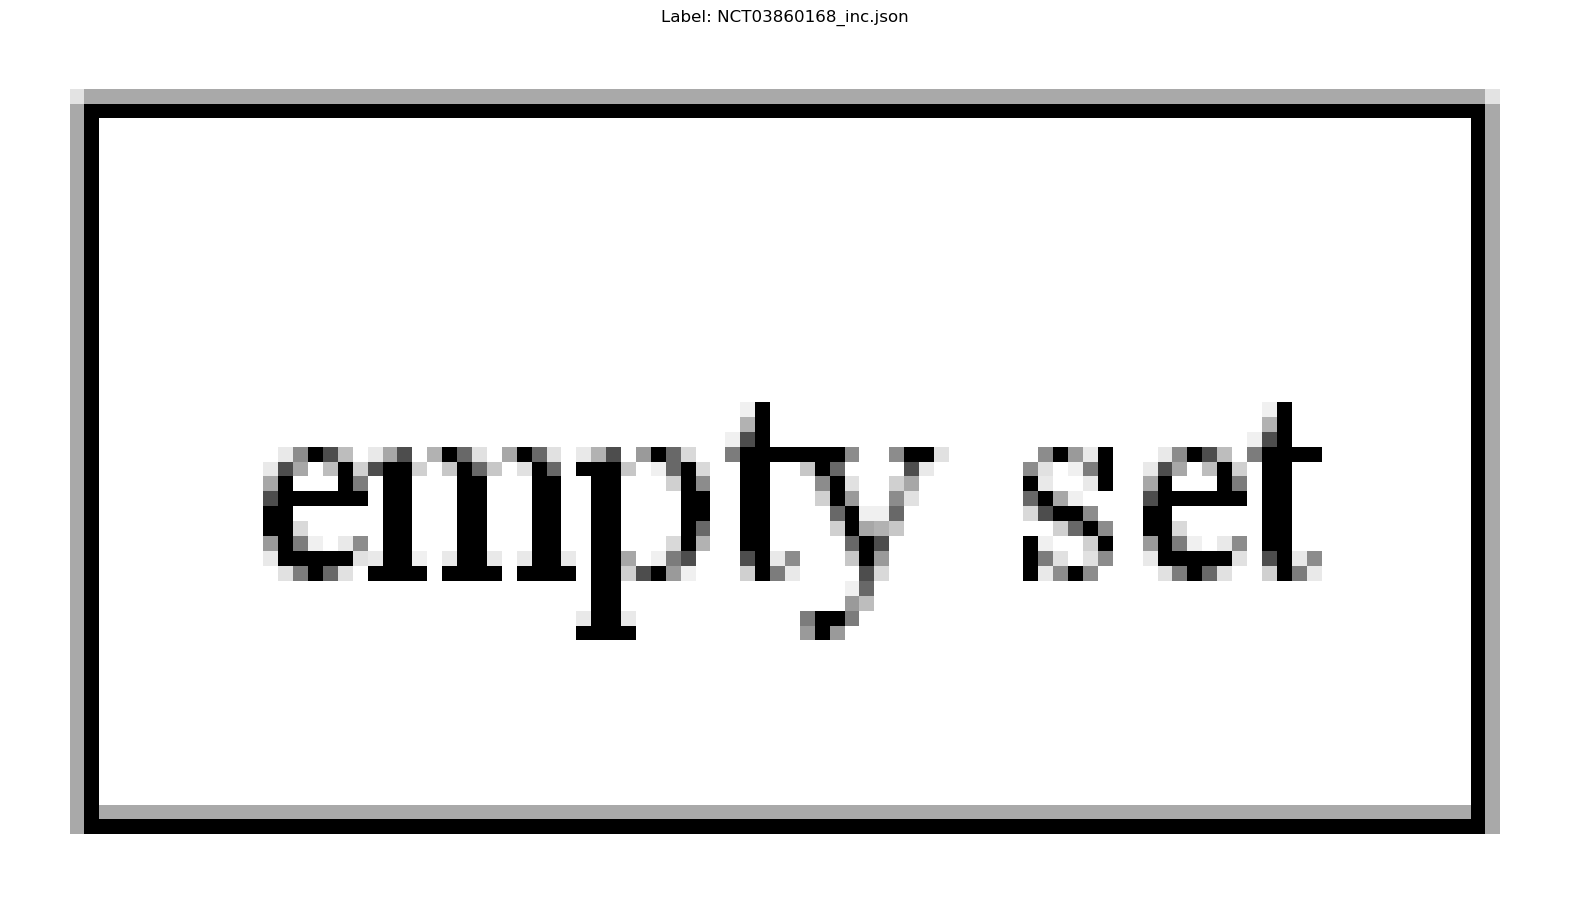

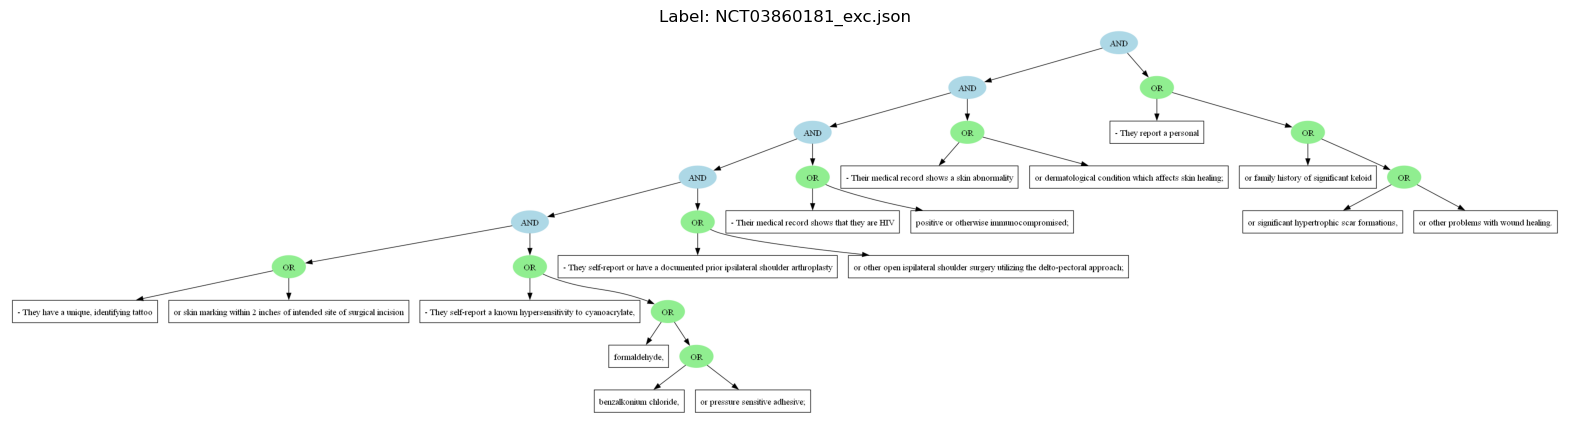

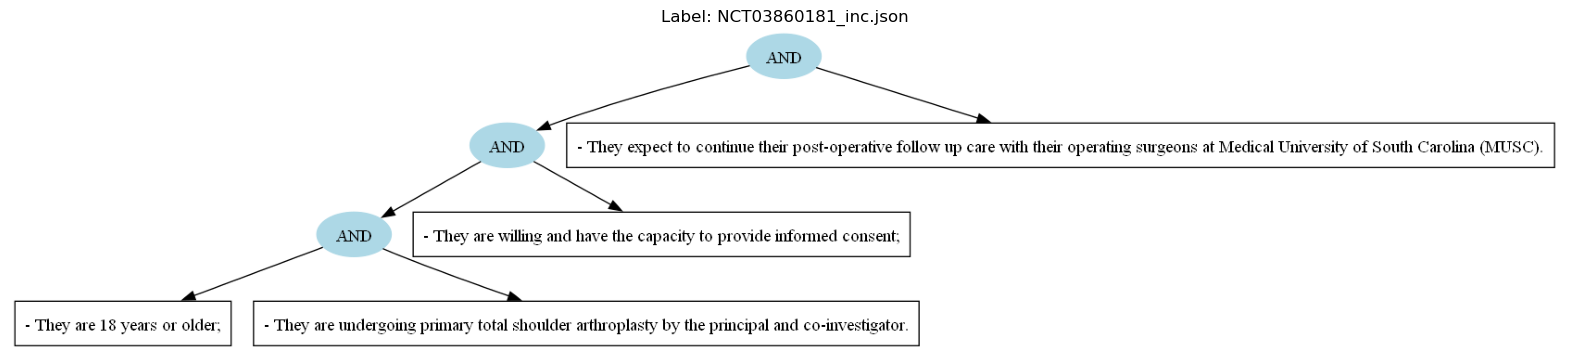

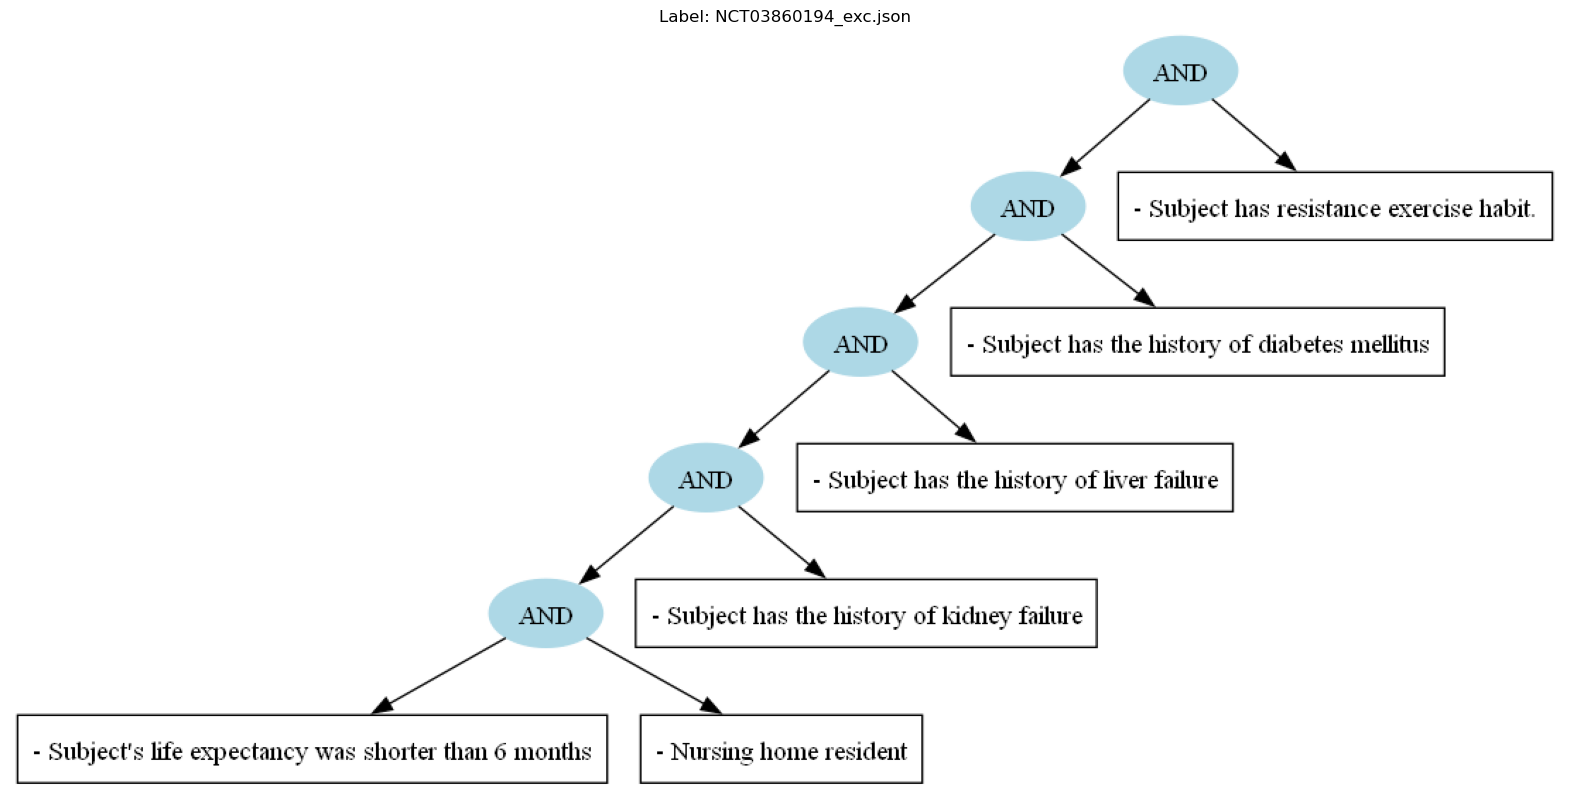

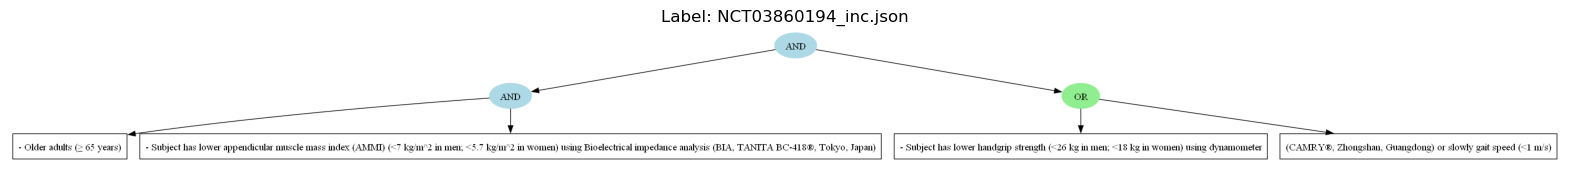

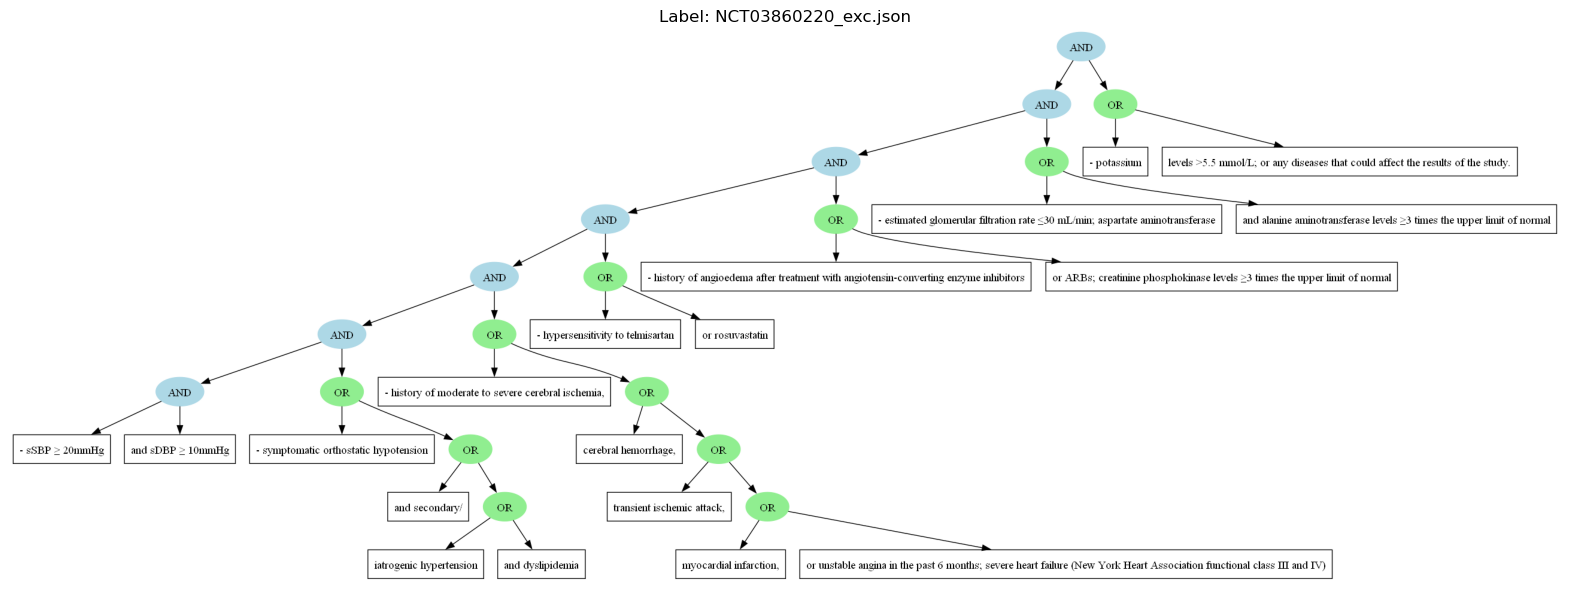

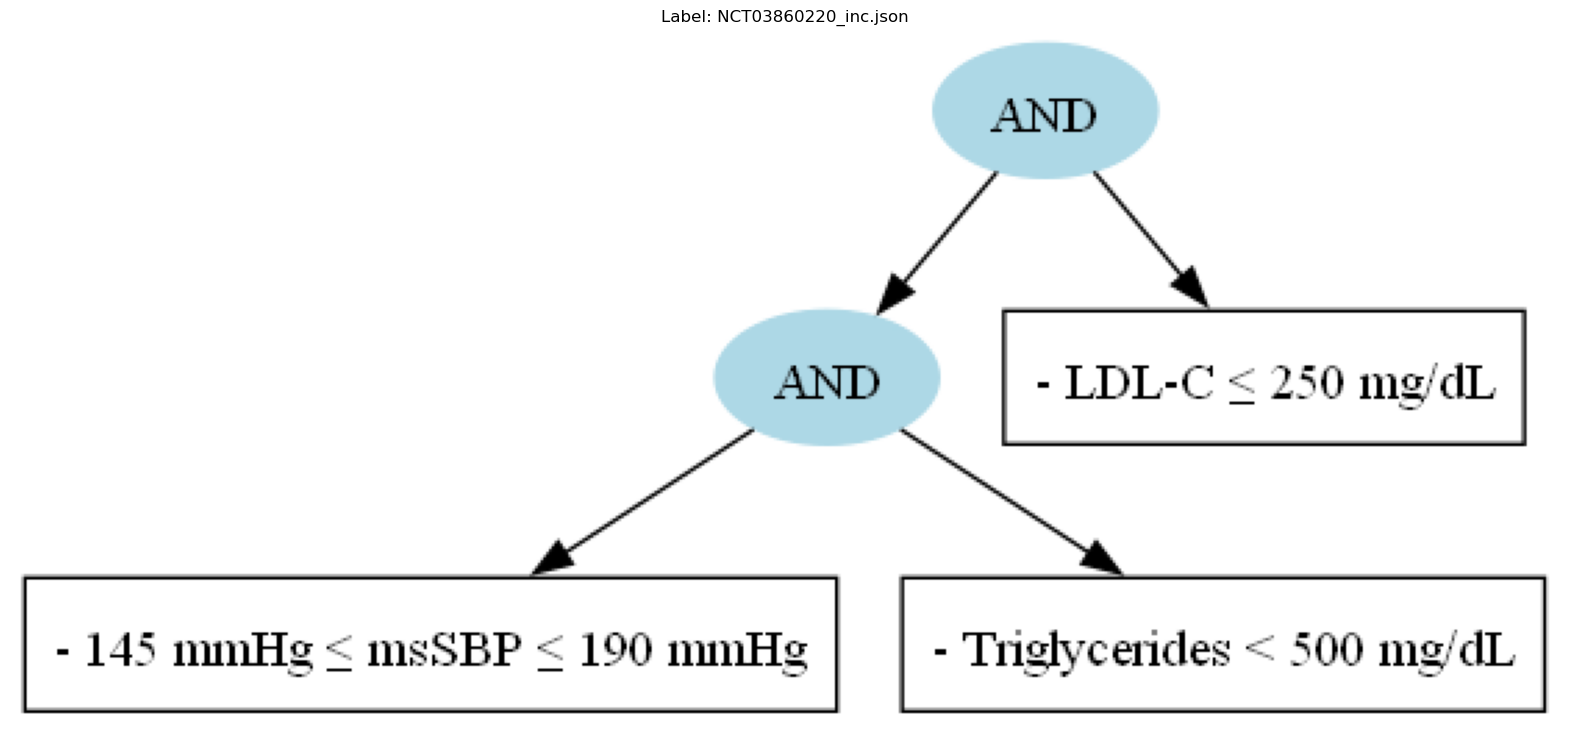

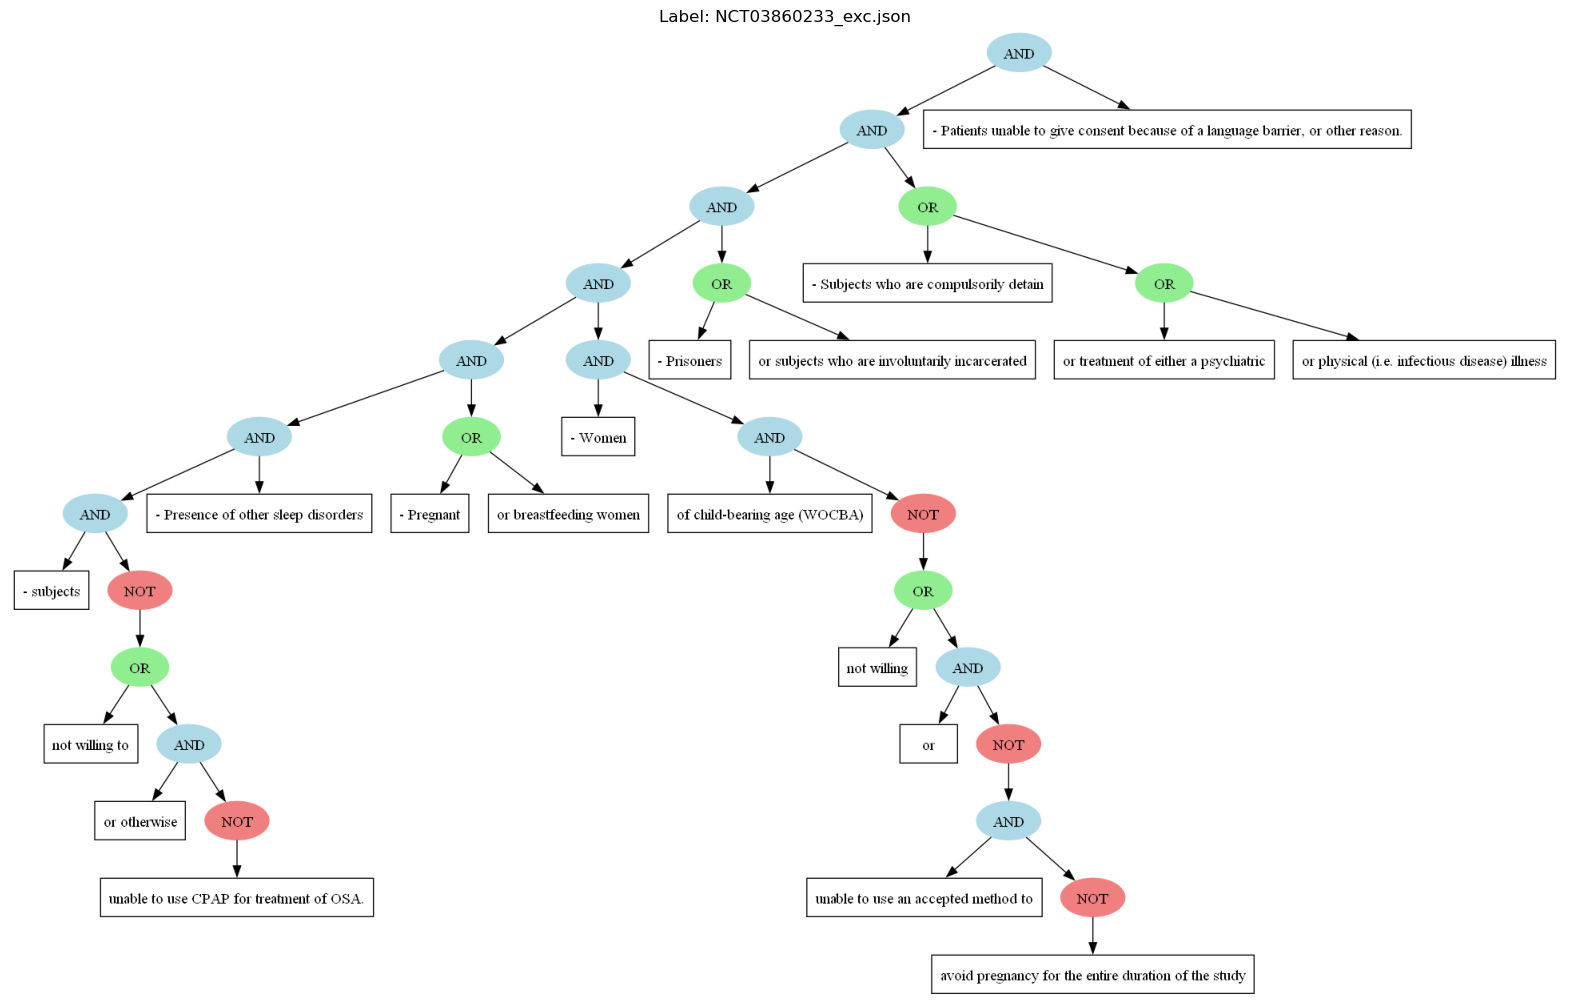

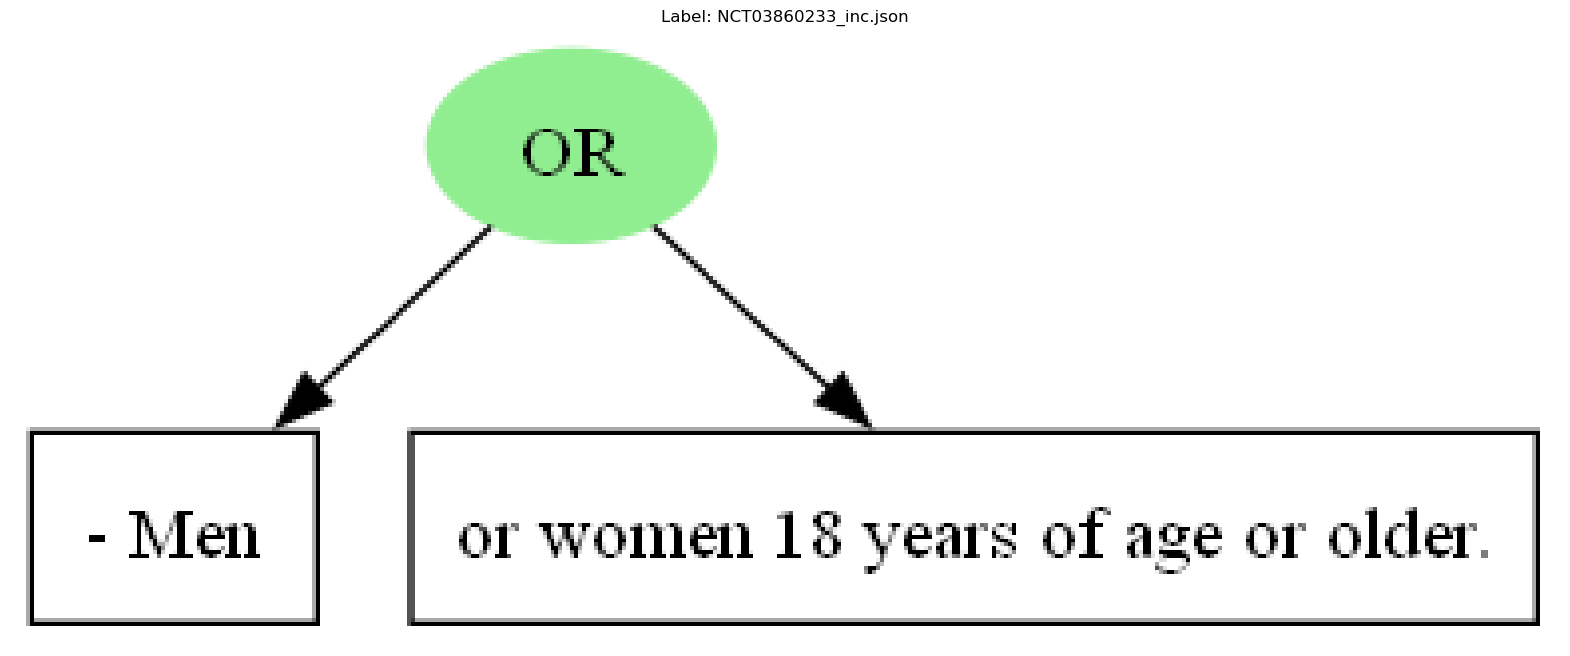

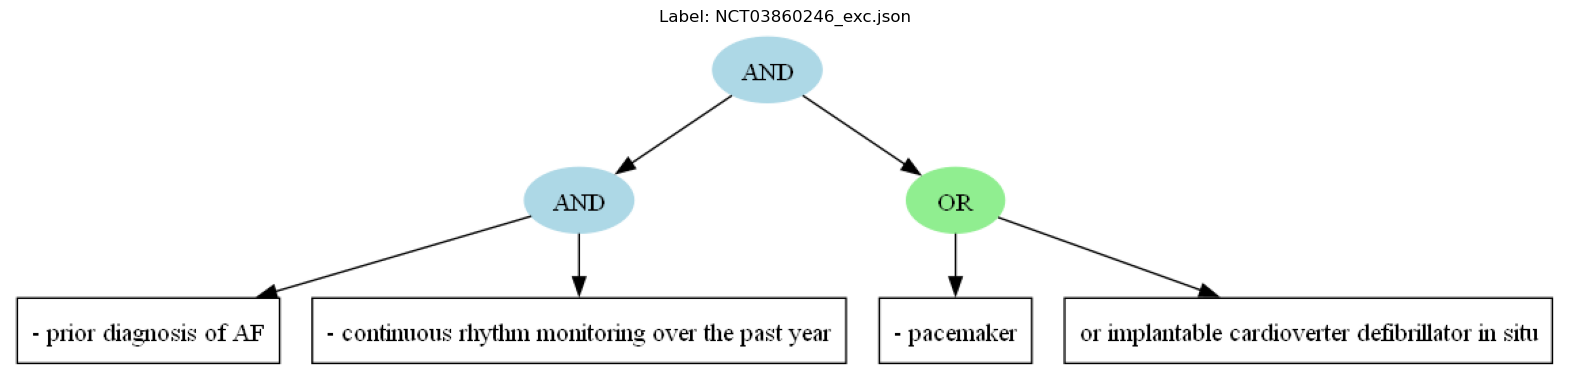

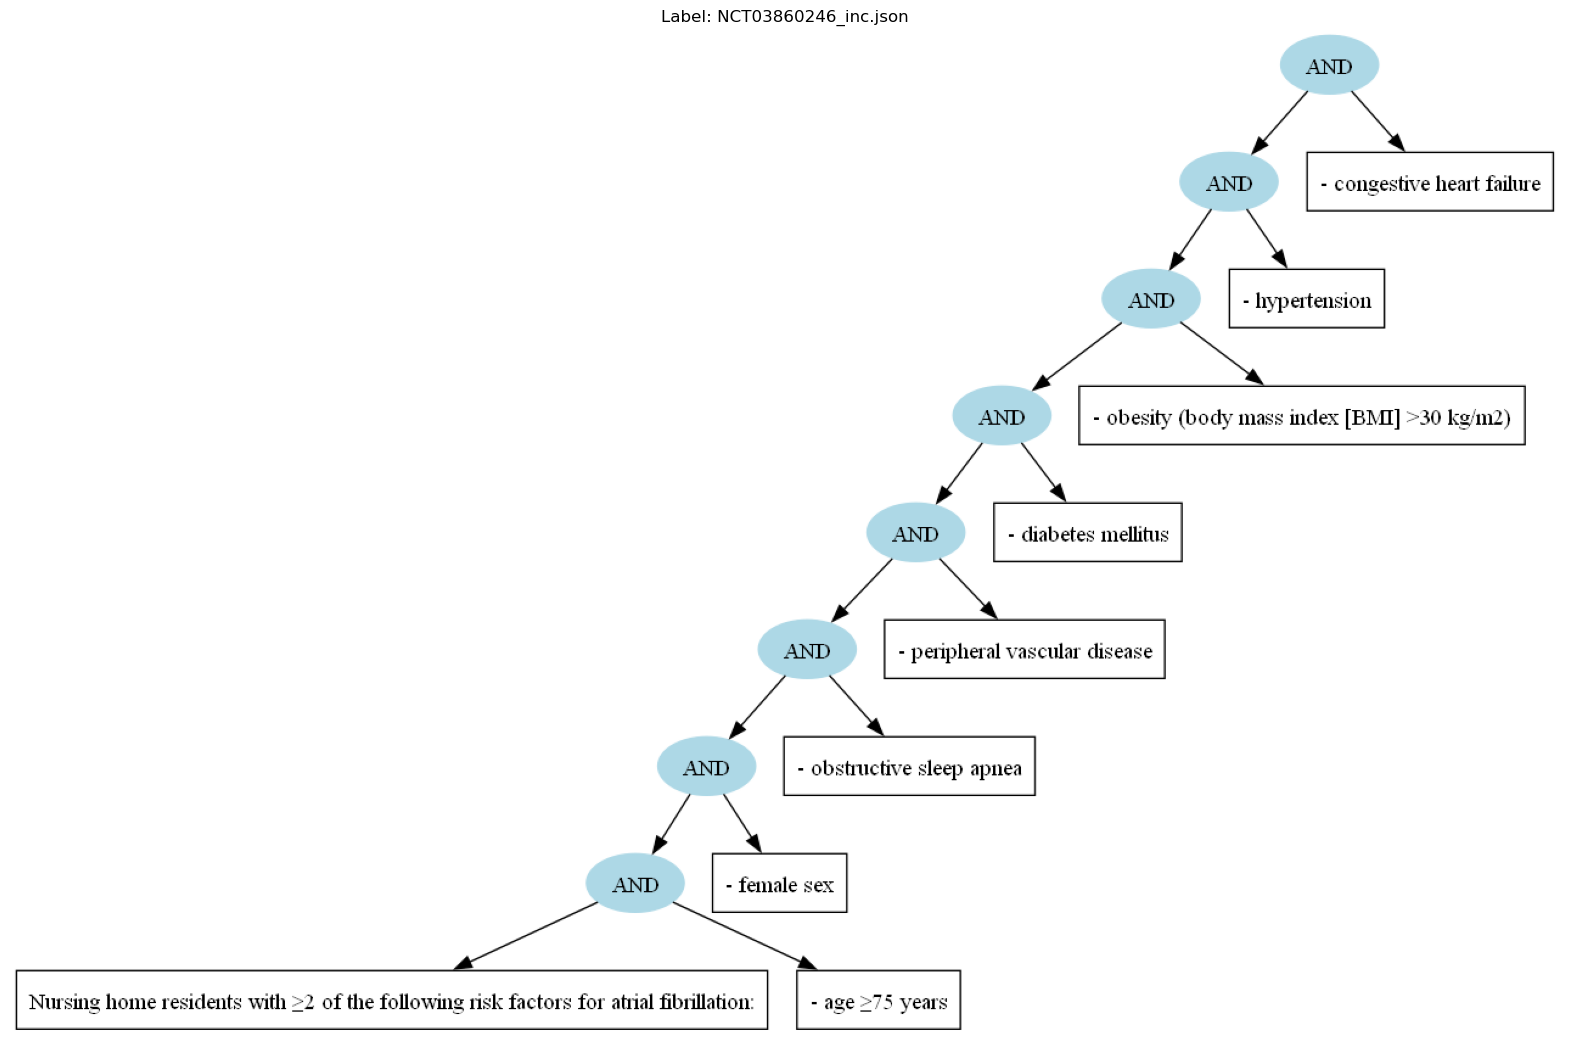

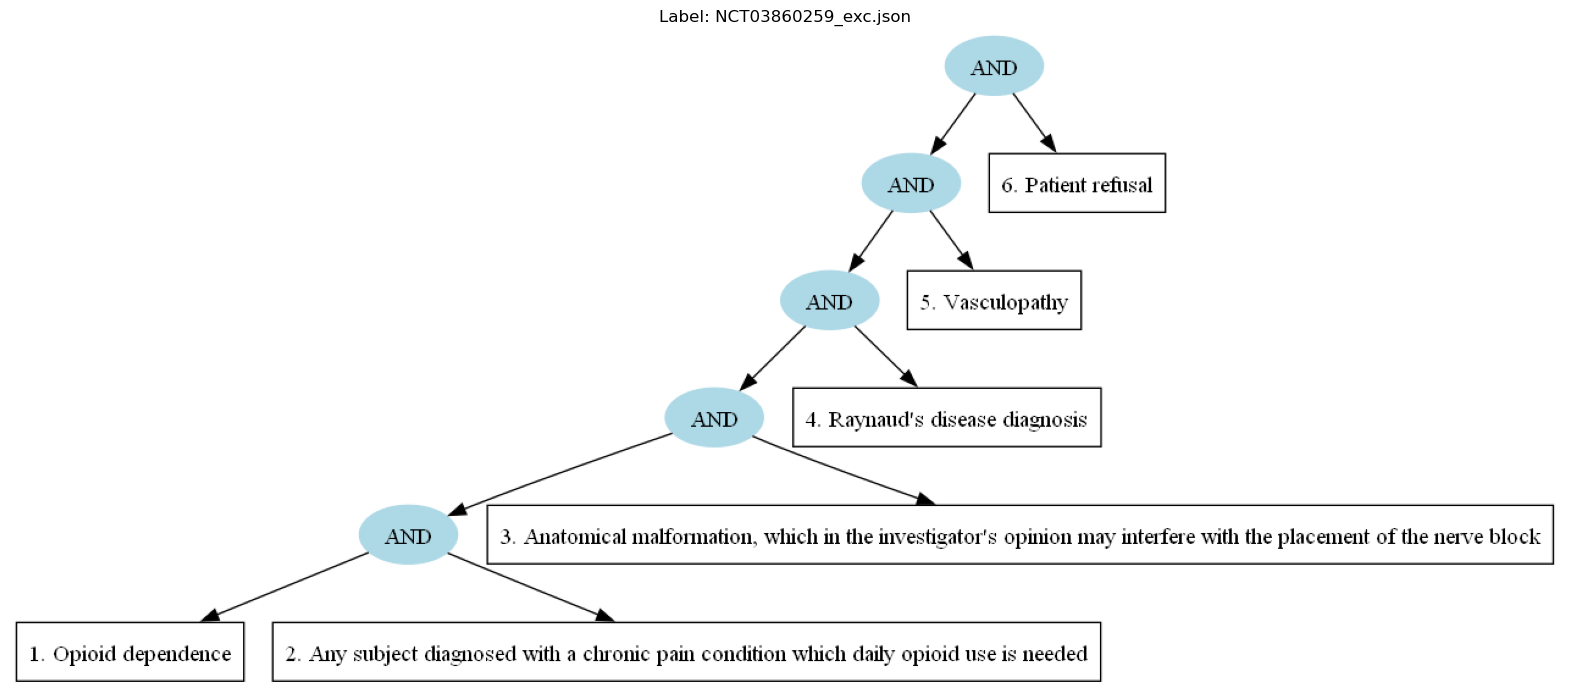

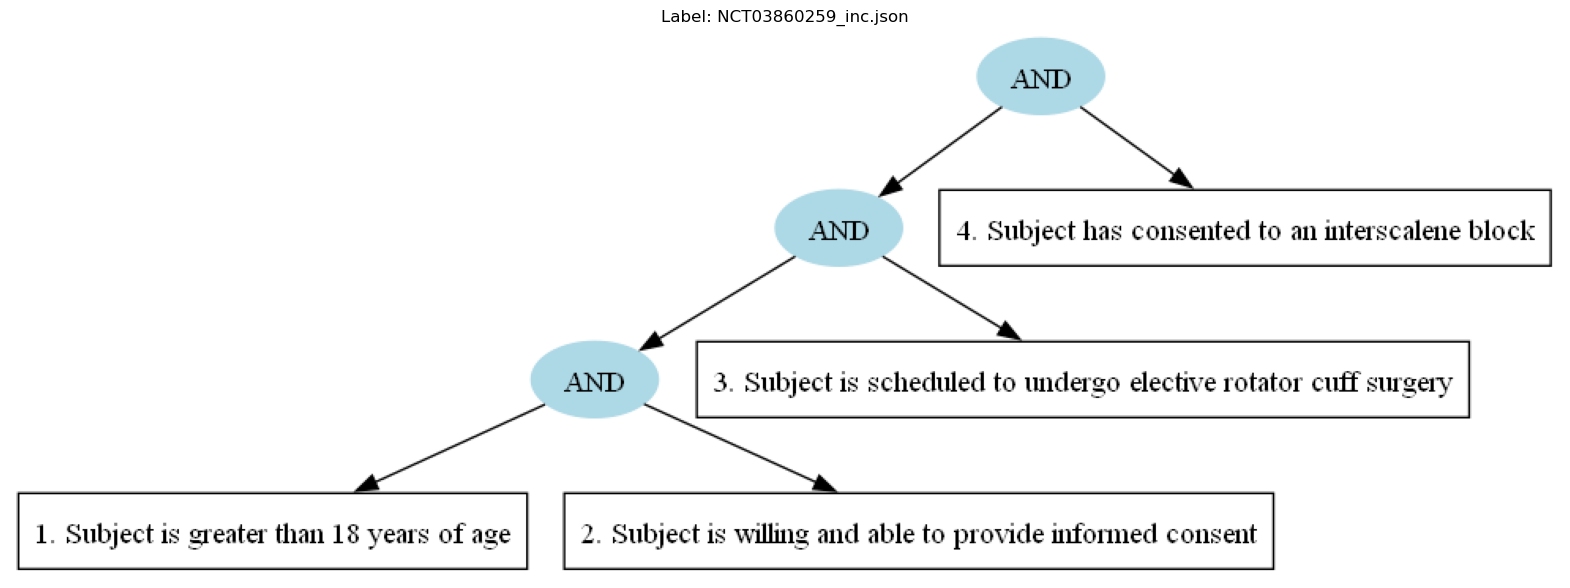

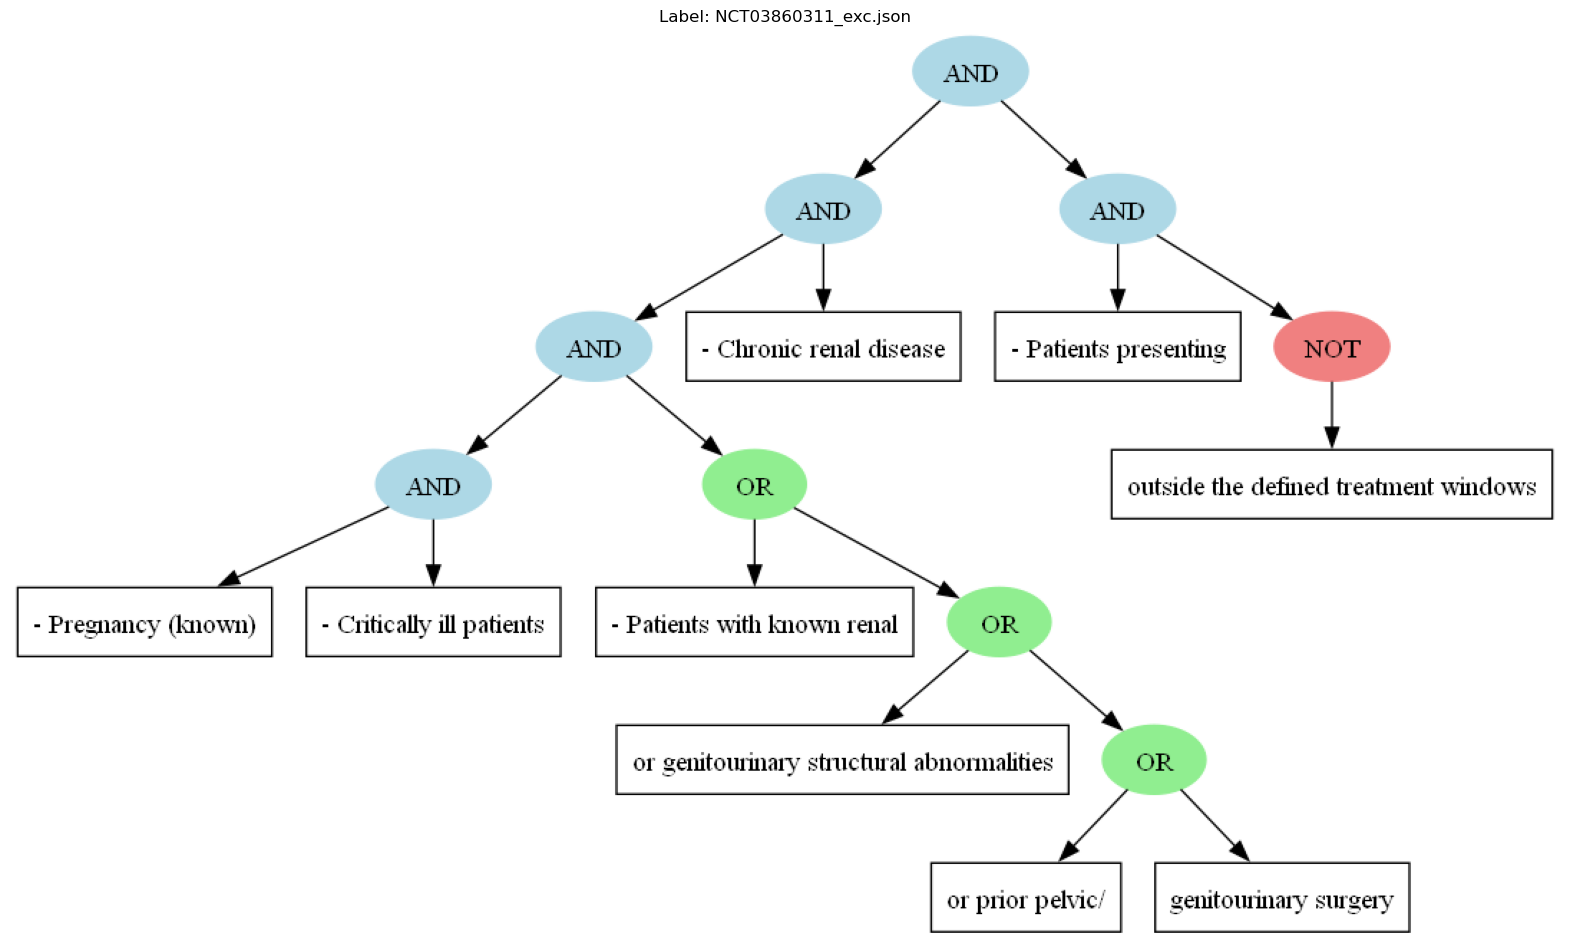

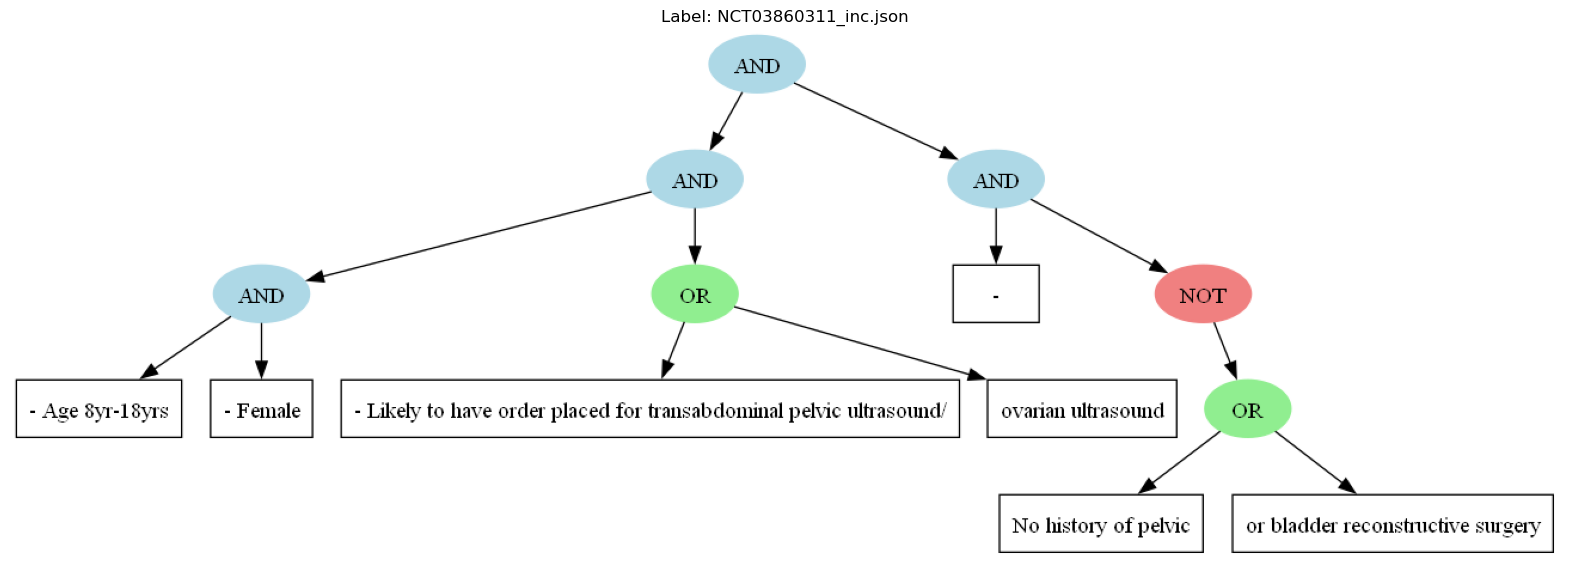

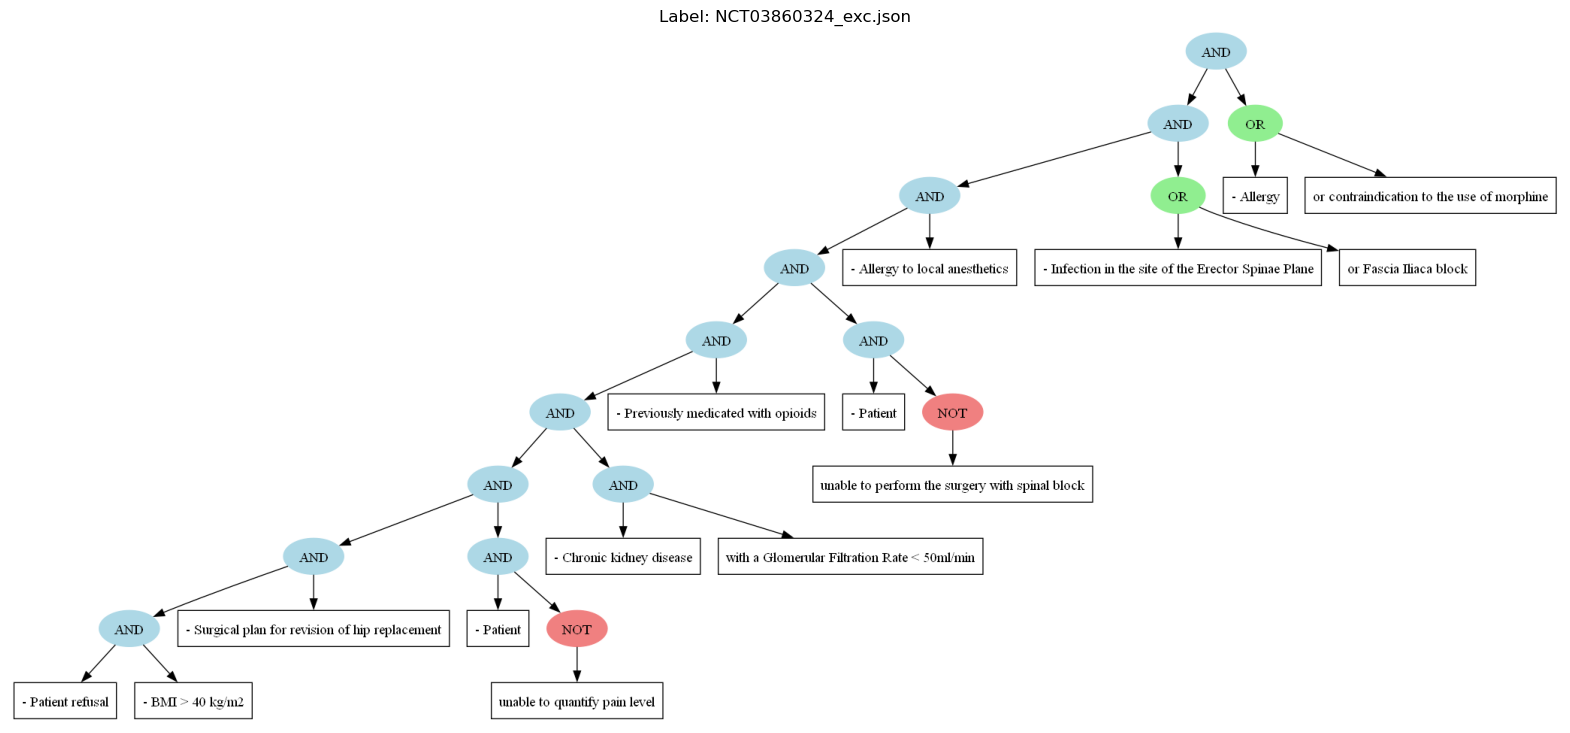

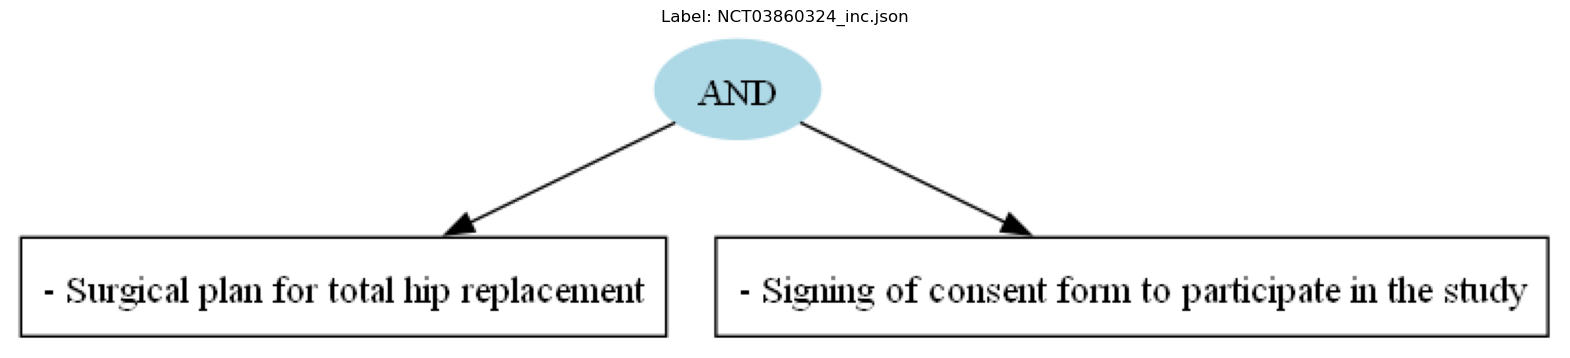

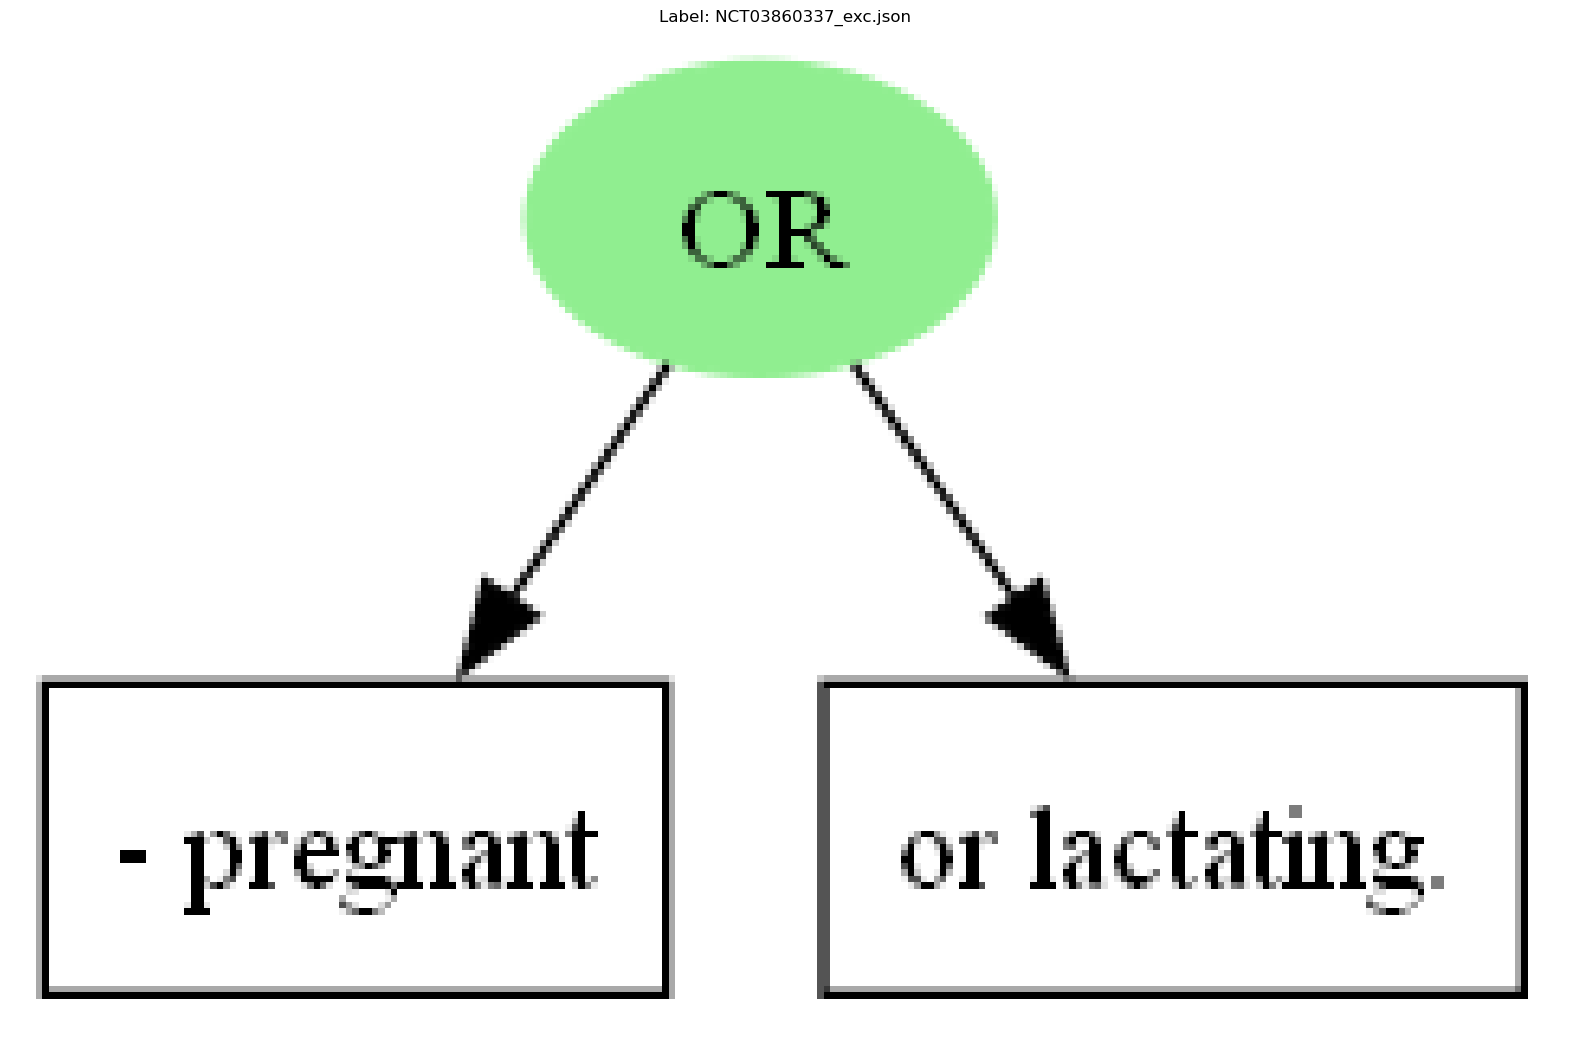

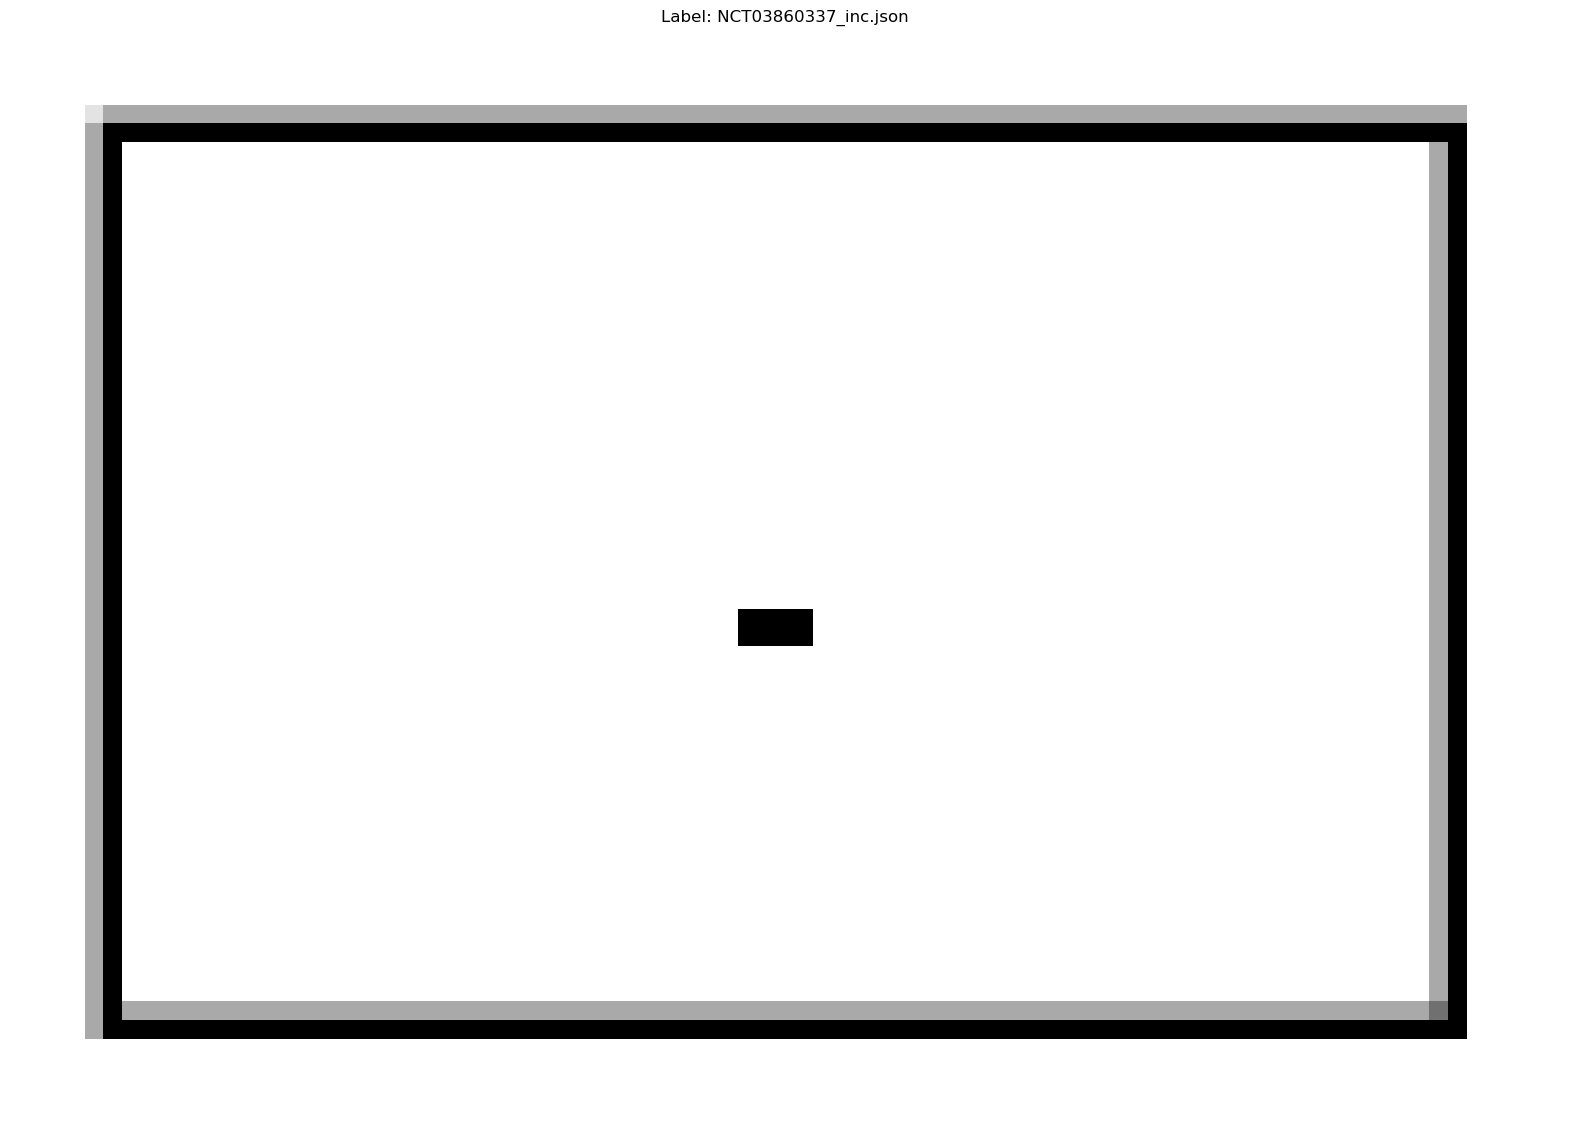

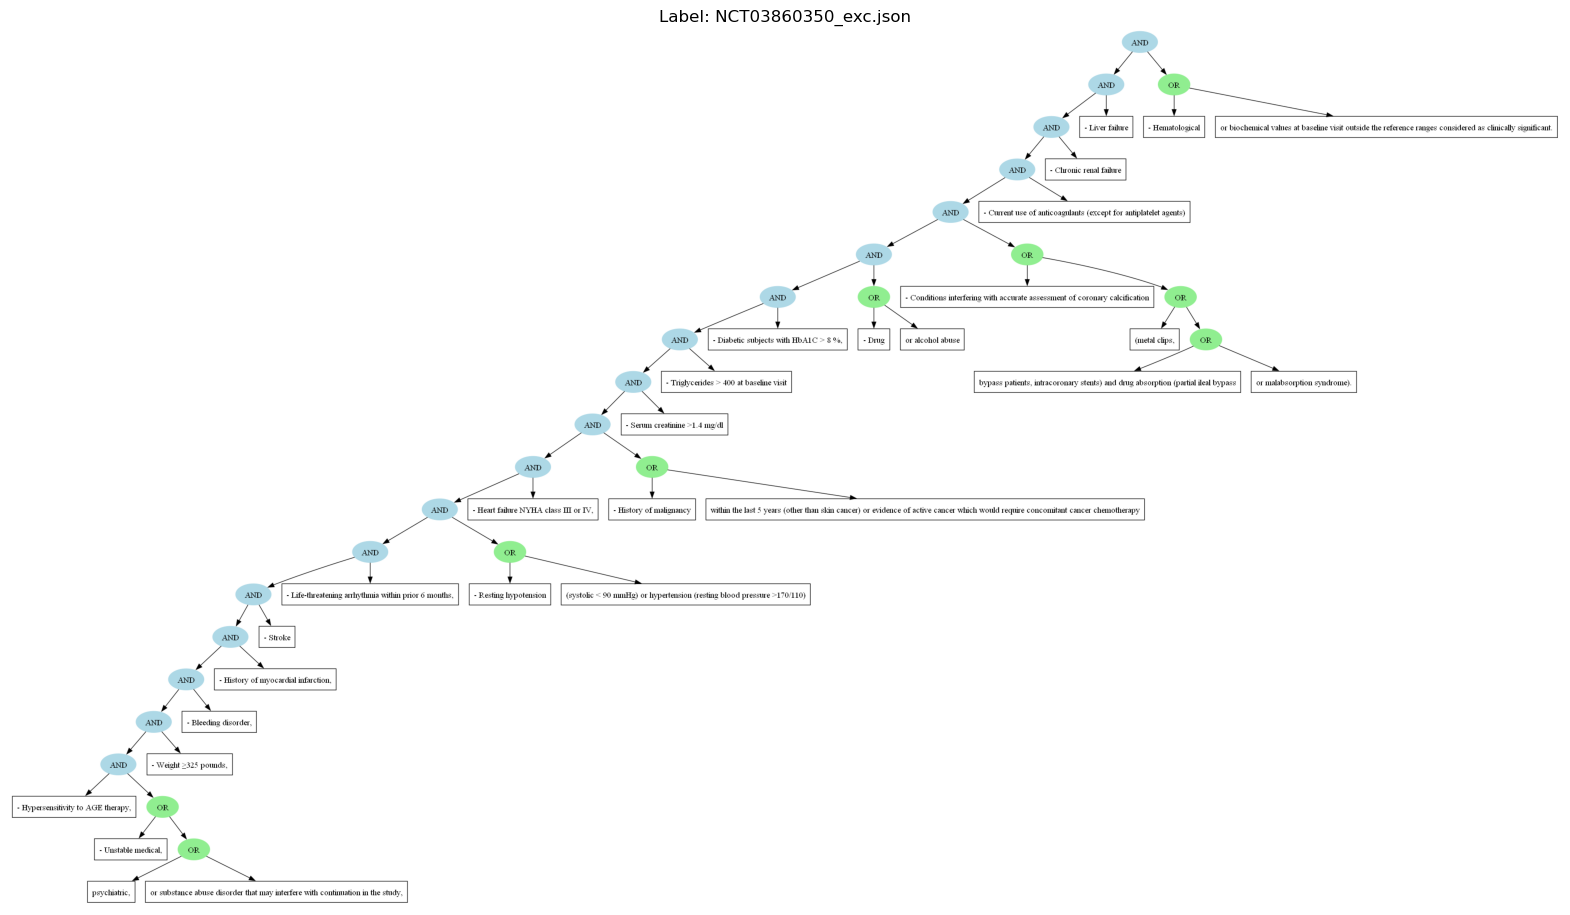

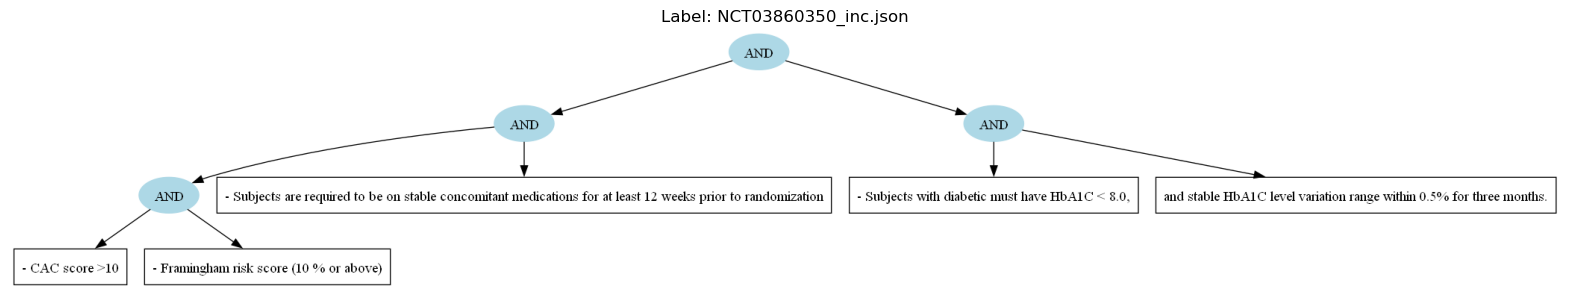

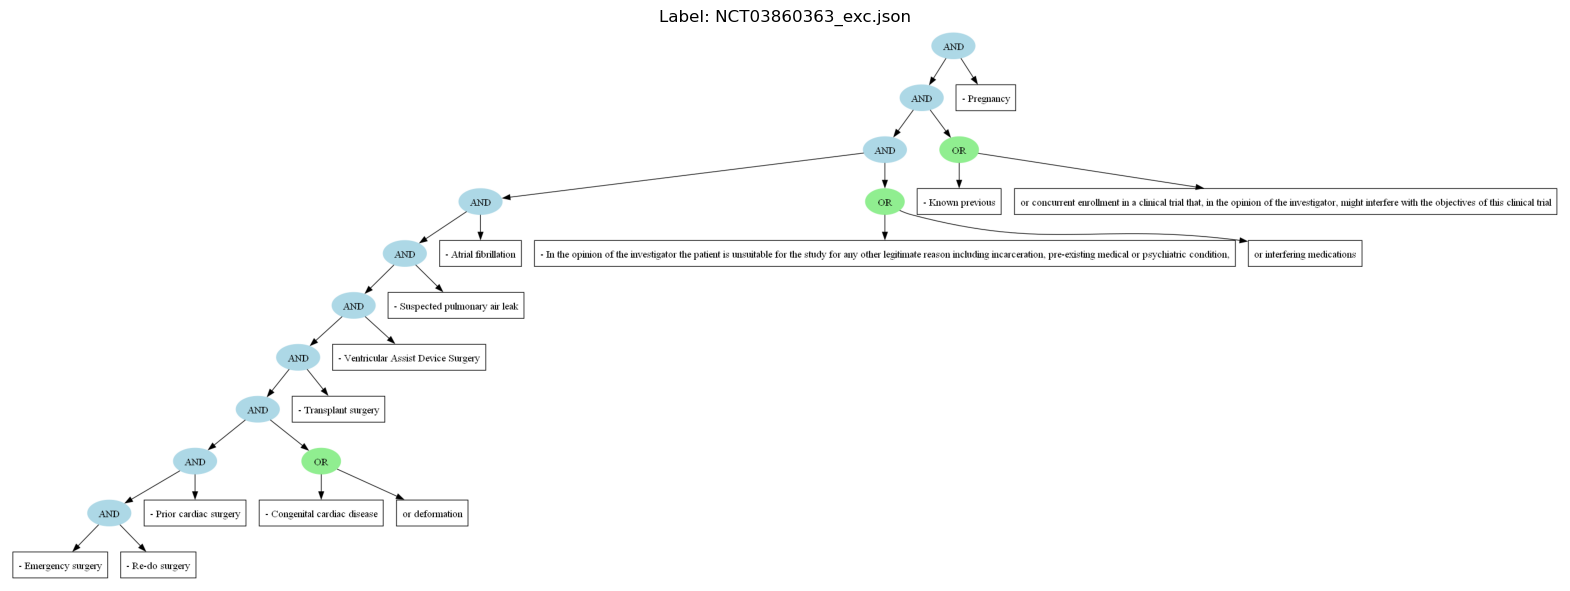

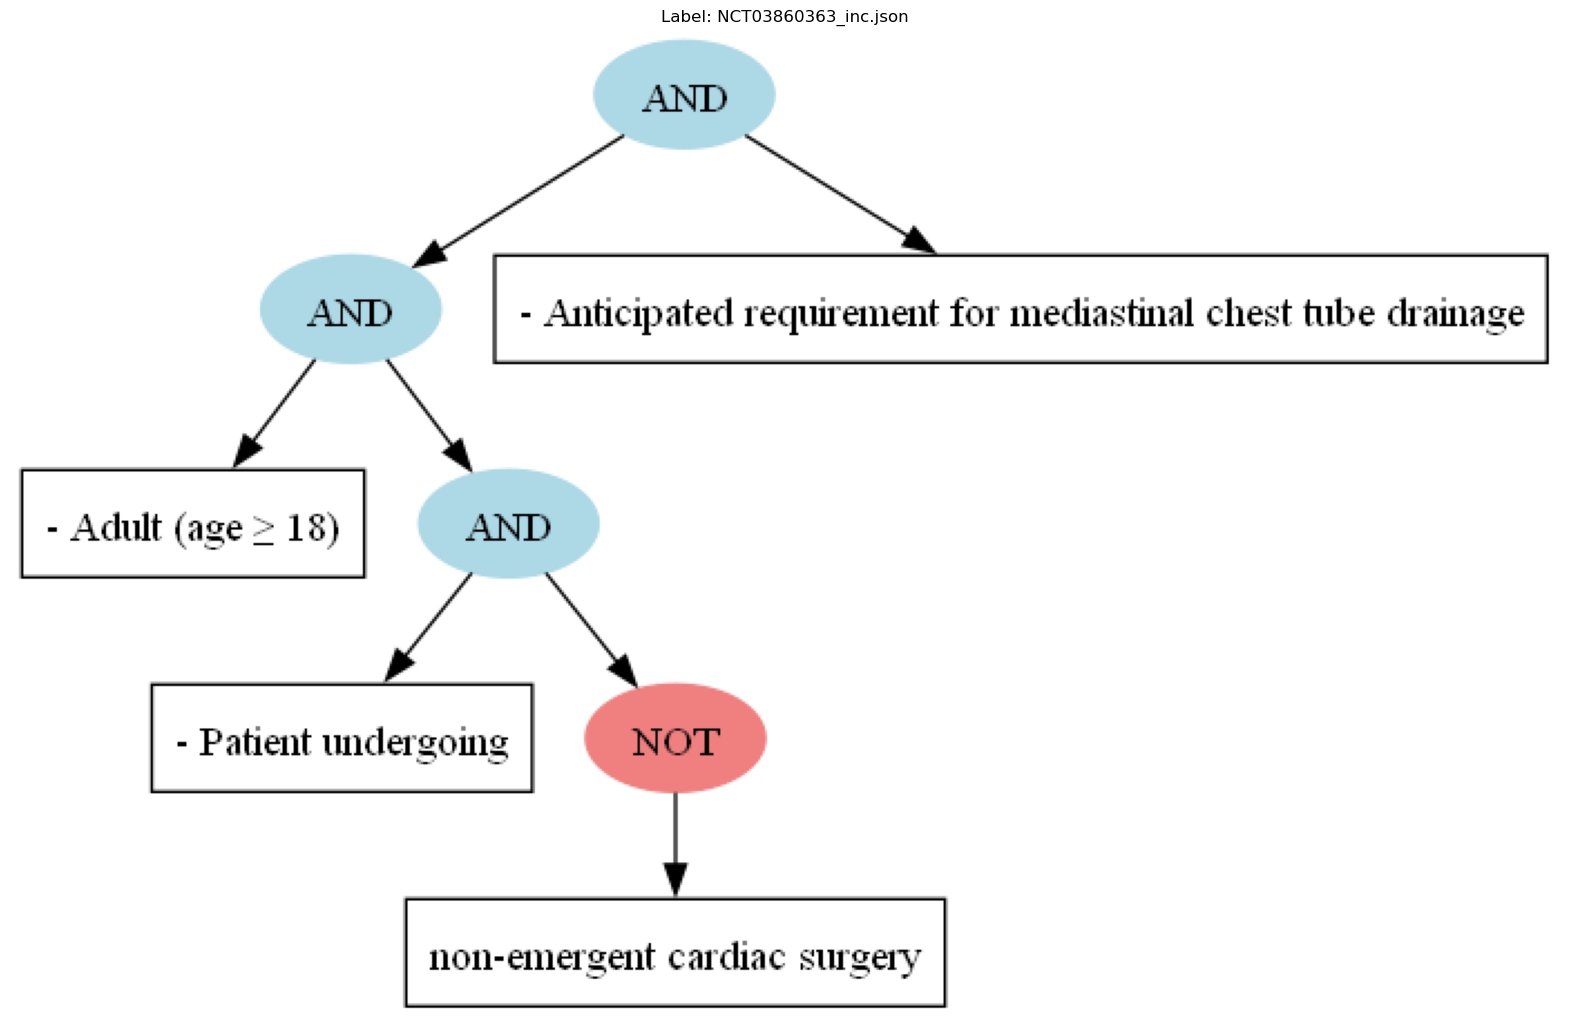

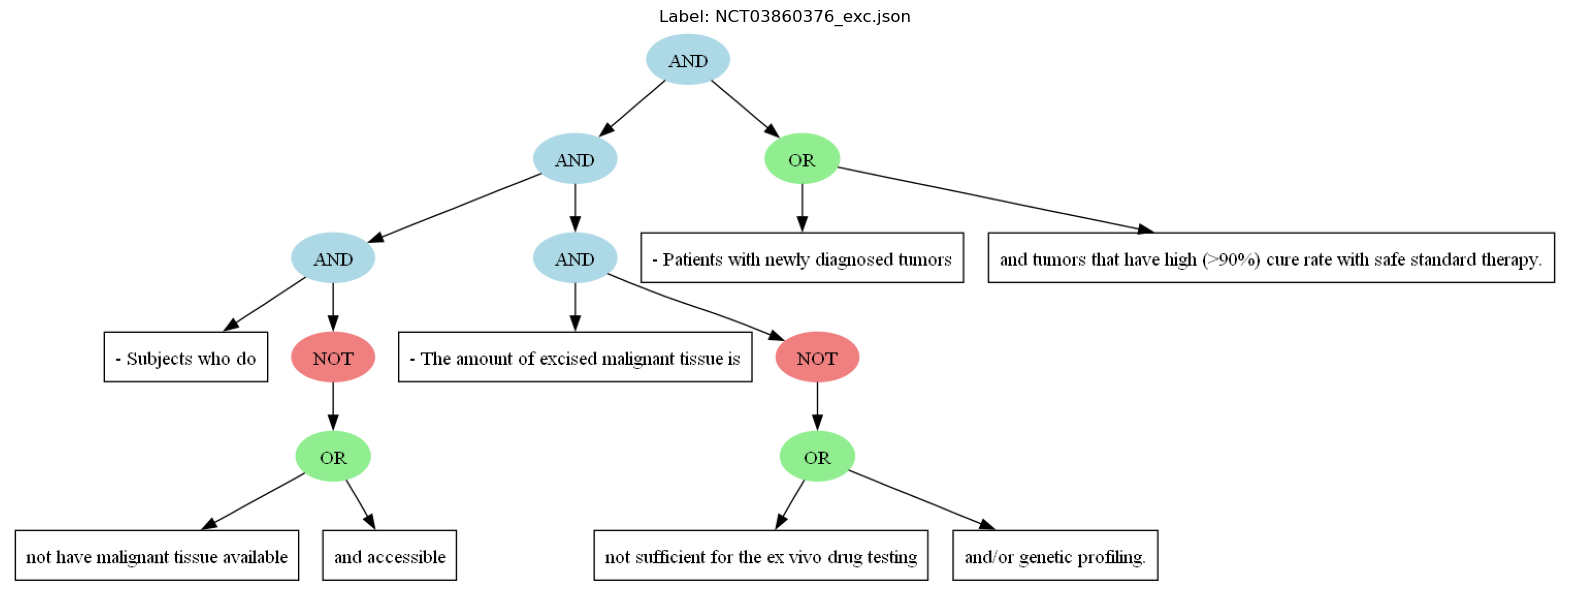

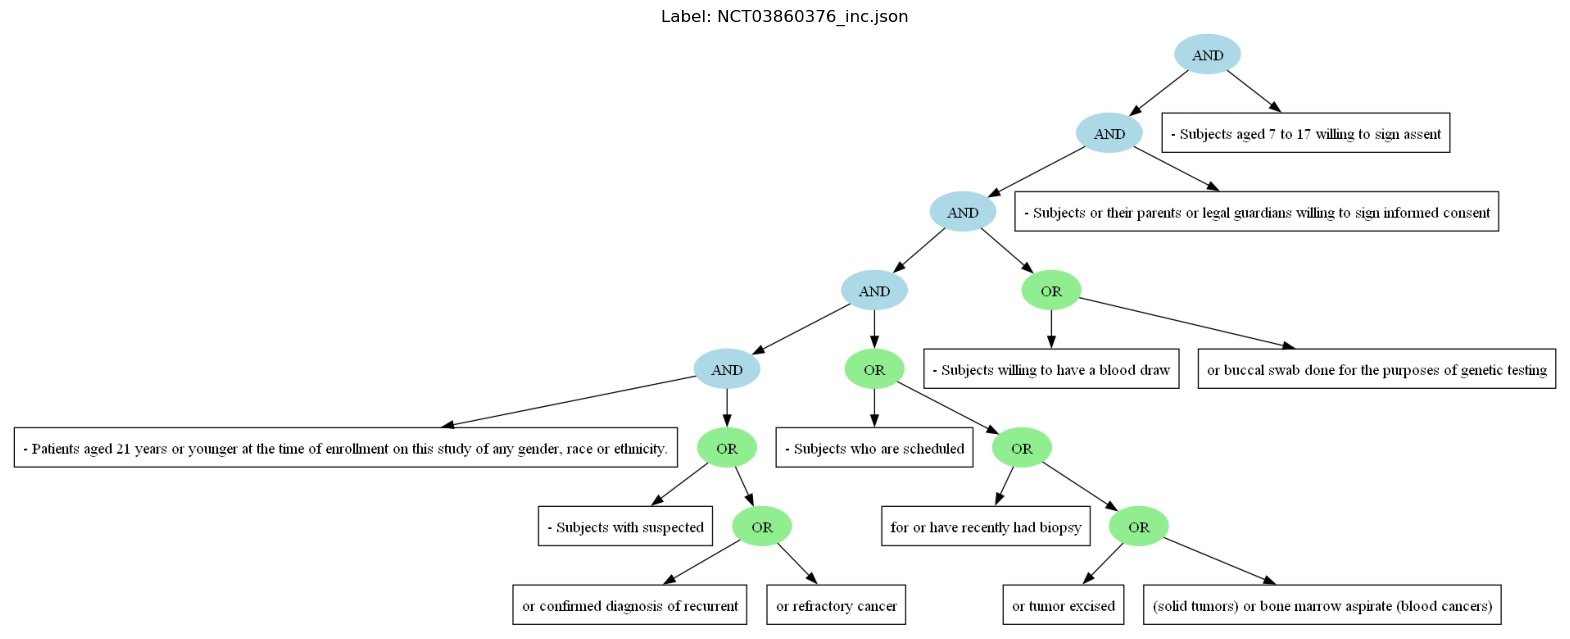

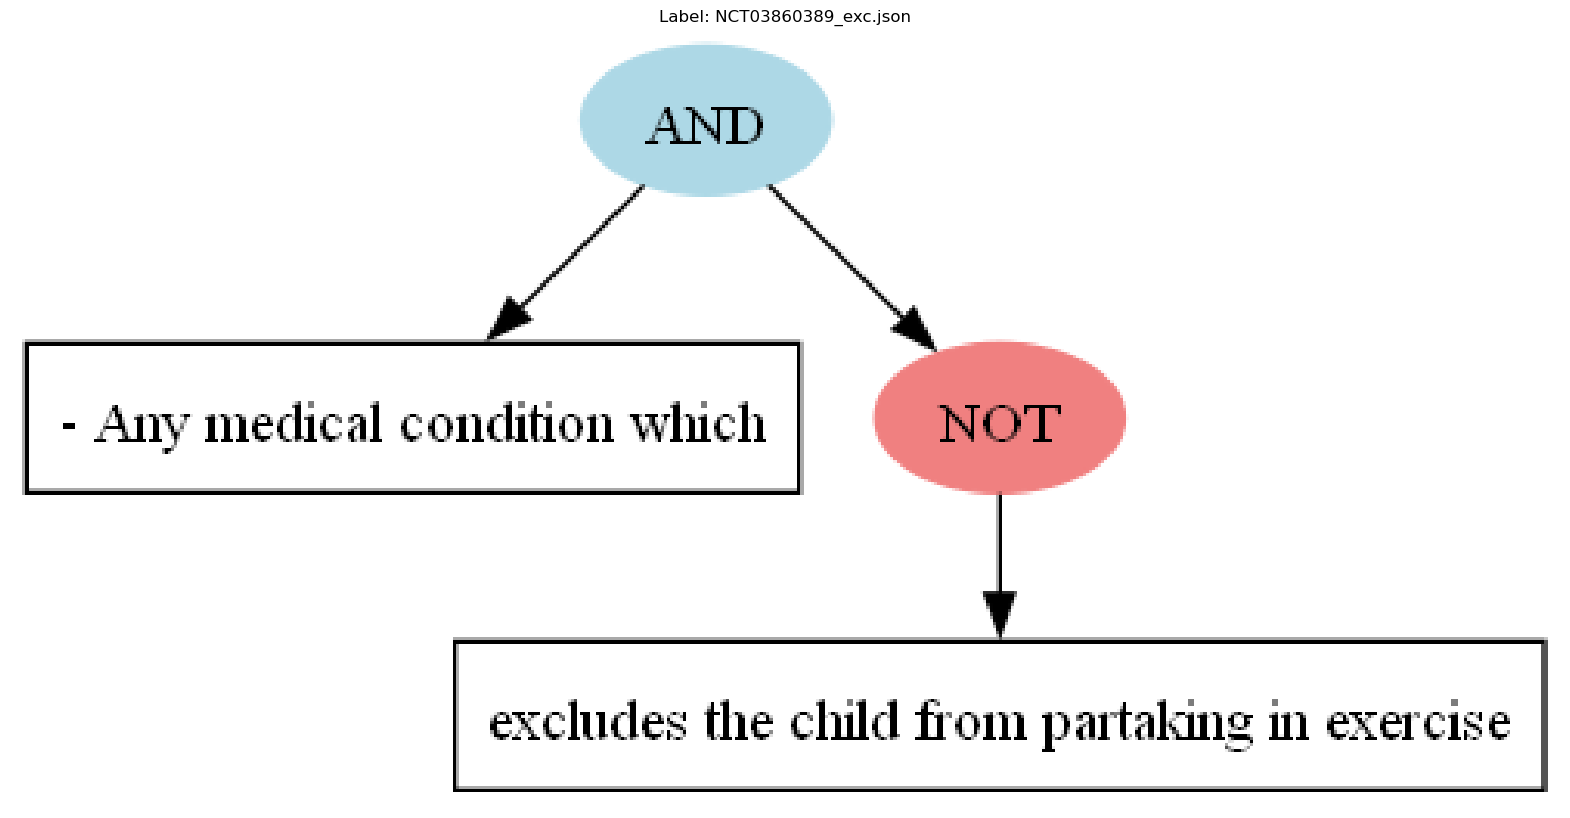

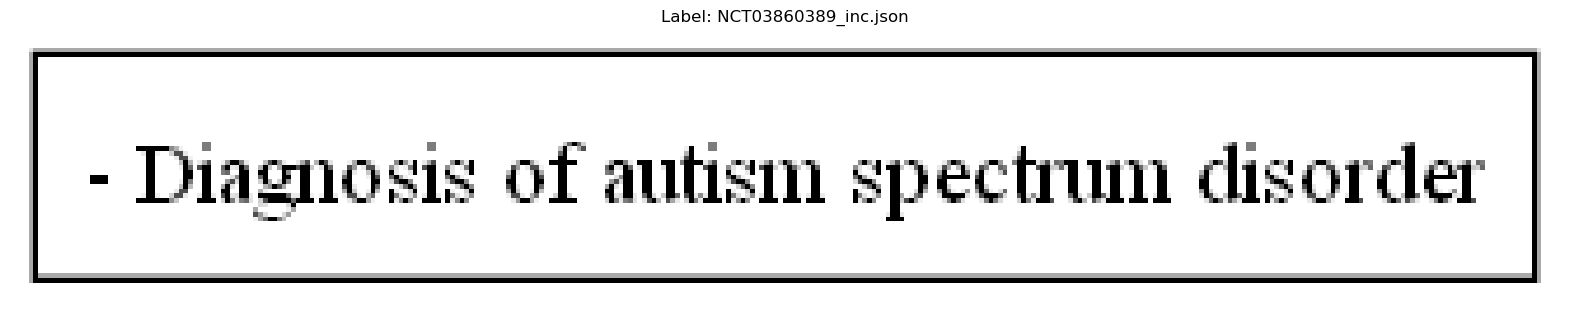

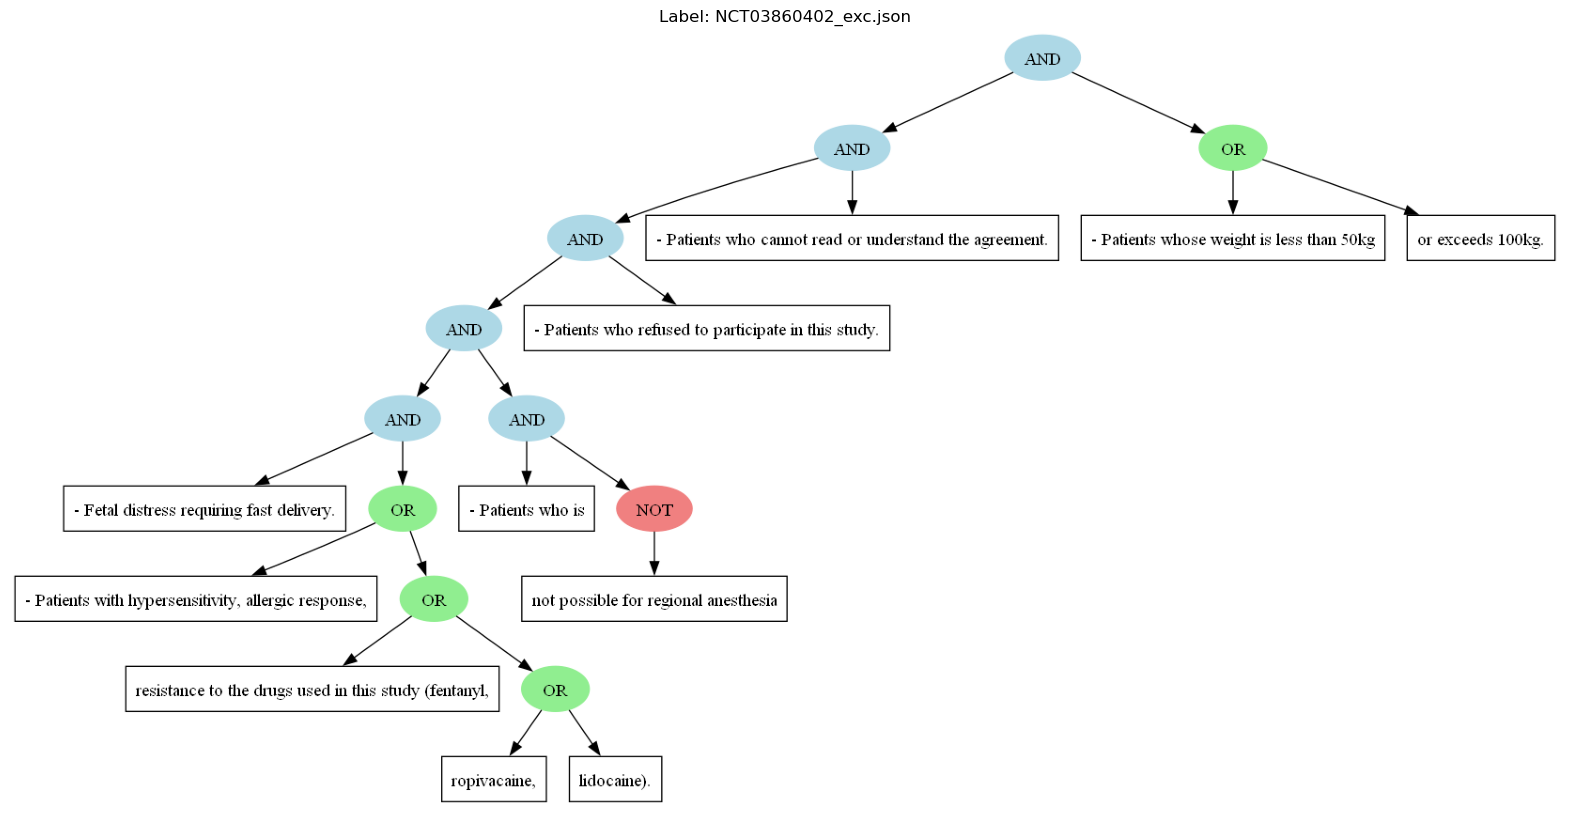

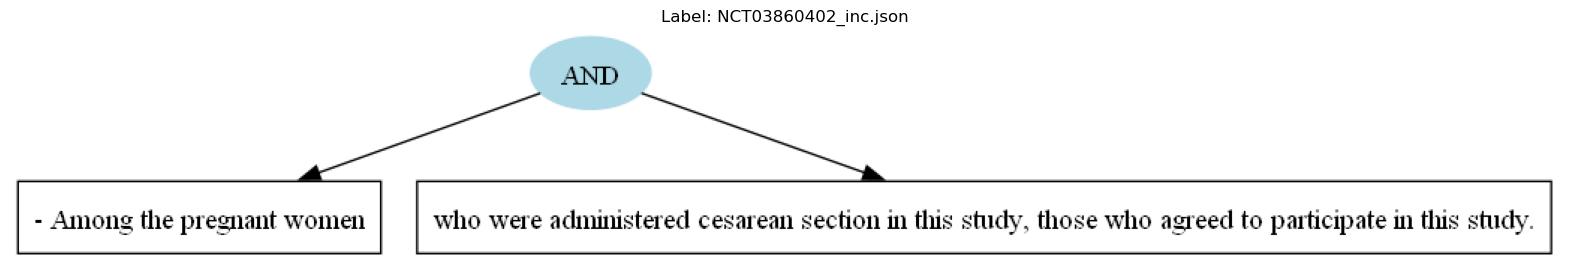

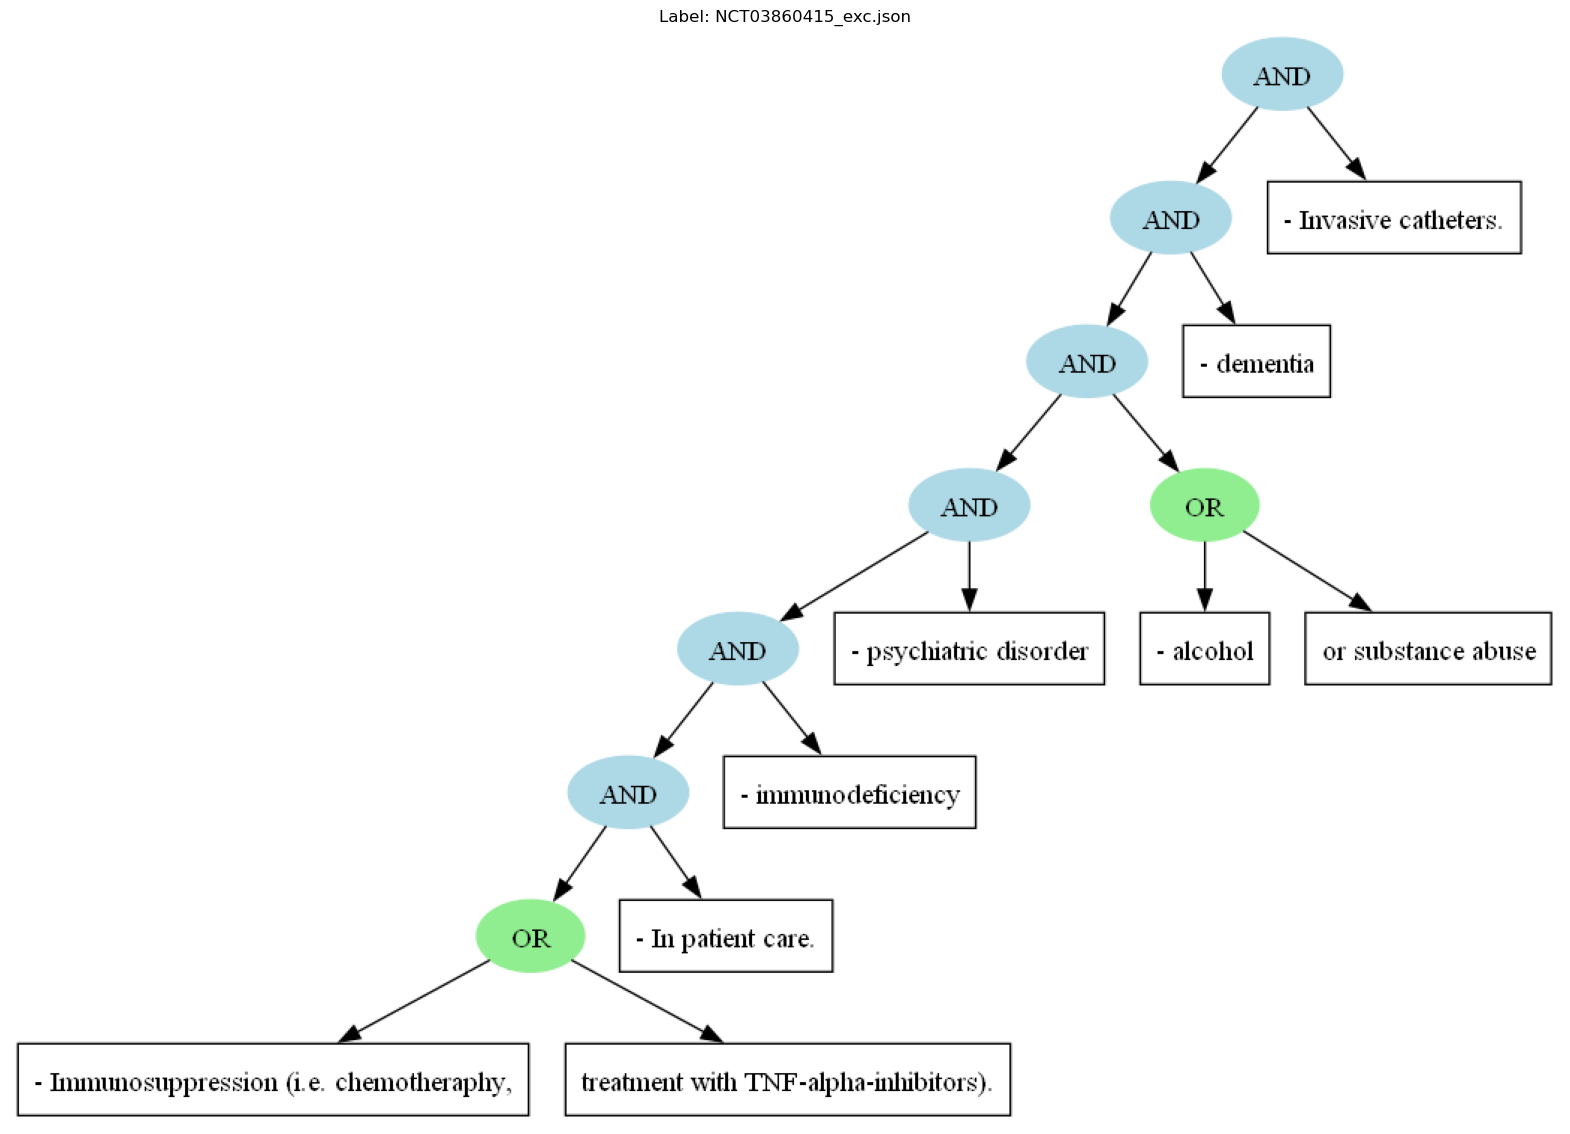

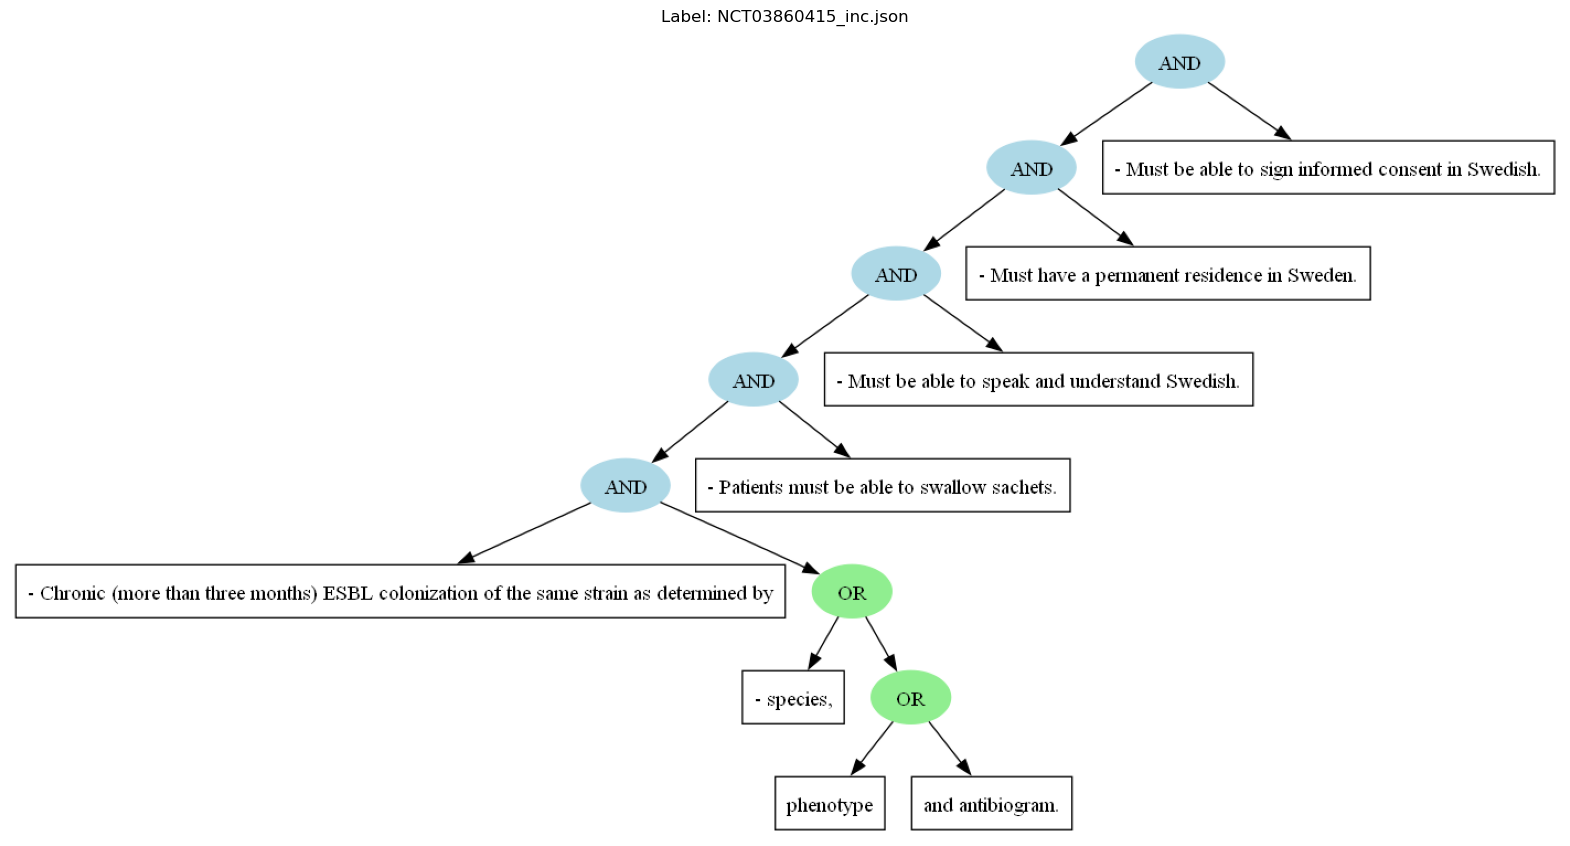

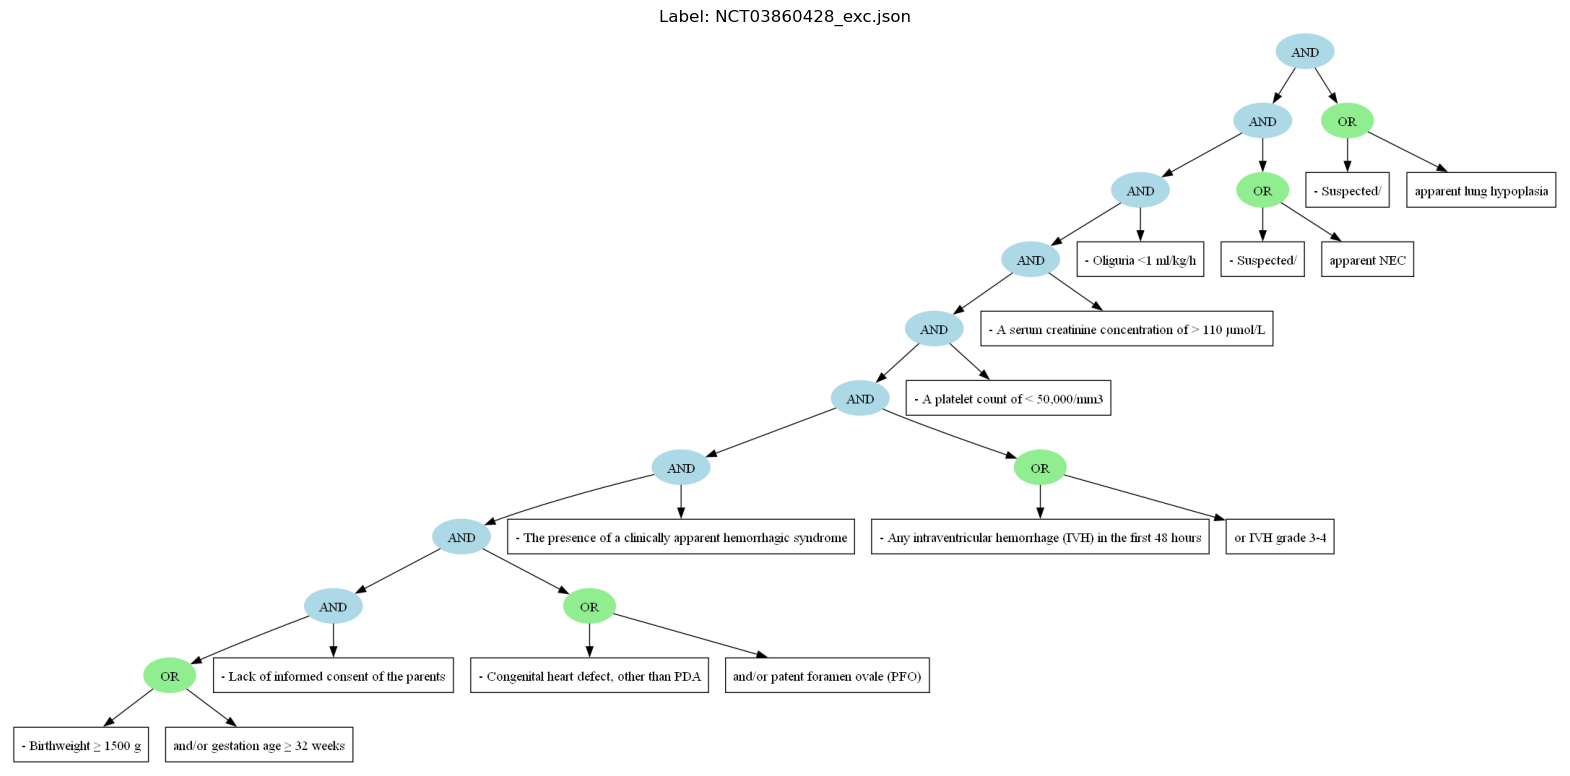

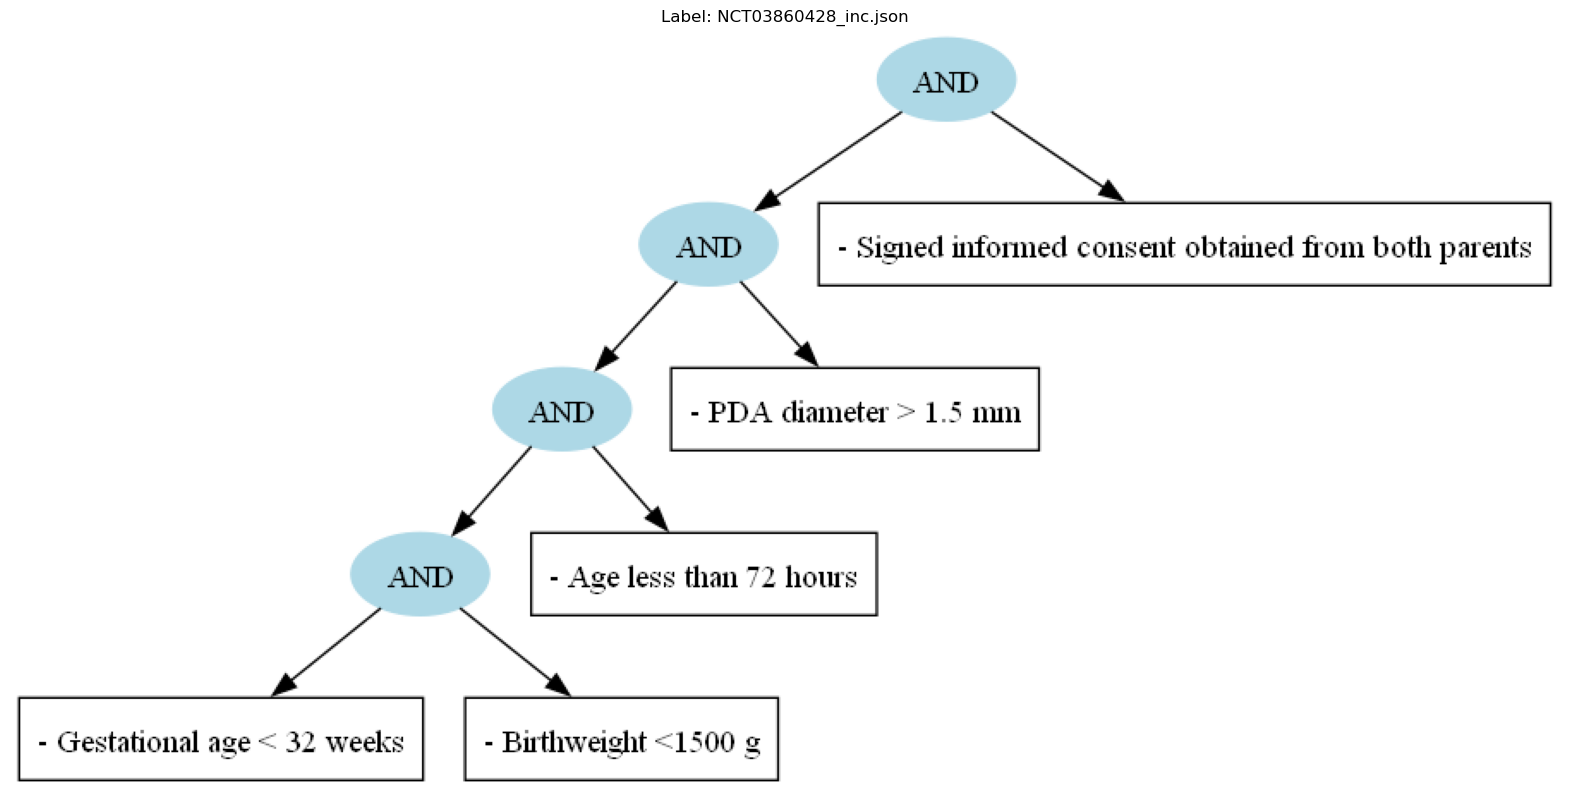

In [21]:
# check label
for label_file in label_files:
    base_name = label_file.split(".json")[0]

    label_file_path = os.path.join(p2_label_path, label_file)
    with open(label_file_path, 'r', encoding='utf-8') as f:
        label_data = json.load(f)


    label_output_path = os.path.join(picture_path, f"{base_name}_label.png")
    plot_and_save_graph(label_data, f"Label: {base_name}", label_output_path)

#### Plot only Labels

In [ ]:
for label_file in label_files:
    base_name = label_file.split("_parsed_2.json")[0]

    model = model_name.split("_")[0]
    nshot = model_name.split("_")[1]
    model_file = f"{model}_{base_name}_{nshot}_shot.json"
    print(model_file)

    if model_file in model_files:
        label_file_path = os.path.join(p2_label_path, label_file)
        model_file_path = os.path.join(model_input_path, model_file)

        with open(label_file_path, 'r', encoding='utf-8') as f:
            label_data = json.load(f)

        print("label data: ", label_data)
        label_output_path = os.path.join(picture_path, f"{base_name}_label.png")
        plot_and_save_graph(label_data, f"Label: {base_name}", label_output_path)
        final_label_output_path = os.path.join("evaluate/batch1/label_pics", f"{base_name}_label.png")
        os.makedirs(os.path.dirname(final_label_output_path), exist_ok=True)
        os.rename(label_output_path, final_label_output_path)